# Notebook - Find best Drug compound for different bacteria
- Bacillus subtilis (Gram positive)
- Bacillus Anthracis (Gram positive)
- Bacillus cereus (Gram positive)
- Staphylococcus aureus (Gram positive)
- Enterococcus faecalis (Gram positive)
- Listeria monocytogenes (Gram positive)
- Yersinia Pestis (Gram negative)

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [48]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [49]:
import os
import csv
import numpy as np
import pandas as pd


from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [50]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [51]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [52]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')

### Filter columns

In [53]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestisData_chEMBL_combined.csv
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestisData_chEMBL_combined.csv
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestisData_chEMBL_combined.csv
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestisData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Virus' column

In [54]:
allBacteriaData_chEMBL['Virus'] = allBacteriaData_chEMBL['Virus'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Virus': 'BacteriaClassifier'}, inplace=True)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestis


### Add some randomization

### Rename columns

In [55]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
})
allBacteriaData_chEMBL.head()

,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.25,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.00,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.50,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.00,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.00,Bacillus_subtilis


### Compound Distribution Across Bacteriaes

In [56]:
Bacteria_counts = allBacteriaData_chEMBL['BacteriaClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(allBacteriaData_chEMBL)

print(f"\n{'Bacteria':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for Bacteria, count in Bacteria_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{Bacteria:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique Bacteriaes: {len(Bacteria_counts)}")


Bacteria                            Count   Percentage
----------------------------------------------------------------------
Staphylococcus_aureus              123803       75.76%
Enterococcus_faecalis               18742       11.47%
Bacillus_subtilis                   15371        9.41%
Bacillus_cereus                      3402        2.08%
Listeria_monocytogenes               1061        0.65%
Bacillus_anthracis                    856        0.52%
Yersinia_pestis                       187        0.11%
----------------------------------------------------------------------
TOTAL                              163422      100.00%

Number of unique Bacteriaes: 7


### Add `ID` column to left

In [57]:
allBacteriaData_chEMBL.insert(0, 'ID', range(1, len(allBacteriaData_chEMBL) + 1))
allBacteriaData_chEMBL.head()

,ID,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.25,Bacillus_subtilis
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.00,Bacillus_subtilis
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.50,Bacillus_subtilis
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.00,Bacillus_subtilis
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.00,Bacillus_subtilis


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [58]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
allBacteriaData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,0.25,Bacillus_subtilis
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,100.00,Bacillus_subtilis
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,1.50,Bacillus_subtilis
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,16.00,Bacillus_subtilis
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,16.00,Bacillus_subtilis


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [59]:
print("Original shape:", allBacteriaData_chEMBL.shape)

allBacteriaData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['pPotency'].notna() 
    & (allBacteriaData_chEMBL['pPotency'] > 0) & (allBacteriaData_chEMBL['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", allBacteriaData_chEMBL.shape)

Original shape: (163422, 5)
Shape after cleaning 'pPotency' value: (116388, 5)


### Remove duplicate compounds using Compute median potency per (Smiles, Bacteria) pair

In [60]:
duplicates = allBacteriaData_chEMBL.duplicated(subset=['Smiles', 'BacteriaClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 64124


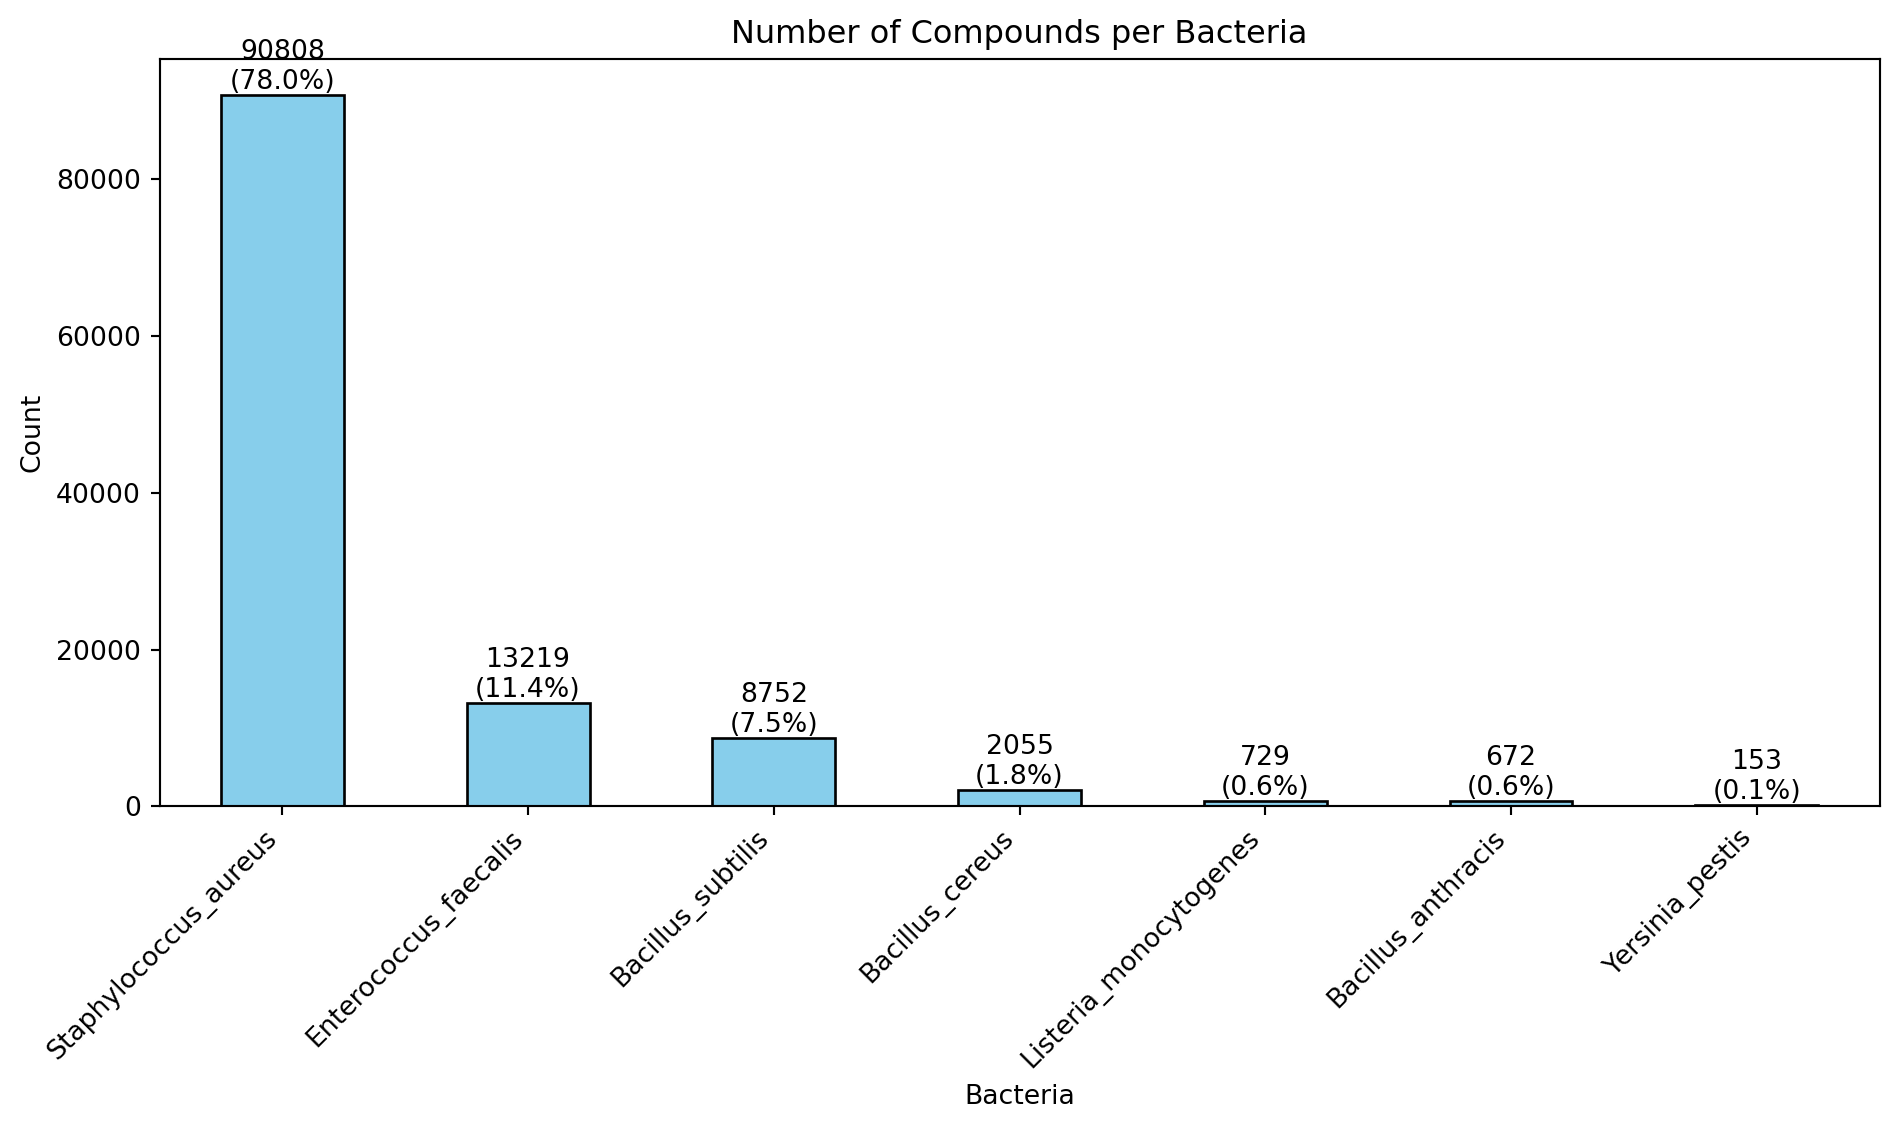

In [61]:
# Get counts and percentages
counts = allBacteriaData_chEMBL['BacteriaClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [62]:
allBacteriaData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "allBacteriaData_chEMBL_MLready.csv"), index=False)

### Arrange bacteria alphabetically

In [63]:
allBacteriaData_chEMBL_ordered = allBacteriaData_chEMBL.sort_values(by='BacteriaClassifier')
allBacteriaData_chEMBL_ordered.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
163123,163124,CHEMBL3311129,c1cc2cc(-c3ccc(-c4cc5ccc(C6=NCCCN6)cc5o4)s3)[n...,0.160000,Bacillus_anthracis
162941,162942,CHEMBL428422,CCN(CC)CCCNc1nc(NCCc2ccccc2)nc(NC23CC4CC(CC(C4...,4.677781,Bacillus_anthracis
162942,162943,CHEMBL4447933,FC(F)(F)c1cc(-c2nnc(Sc3cc(Cl)nc(Sc4ccccc4)n3)[...,0.750000,Bacillus_anthracis
162944,162945,CHEMBL2417988,CCC[C@@H]1C[C@@H](C(=O)NC([C@H]2O[C@H](SC)[C@H...,2.300000,Bacillus_anthracis
162947,162948,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.060000,Bacillus_anthracis


### pPotency value distribution across each bacteria

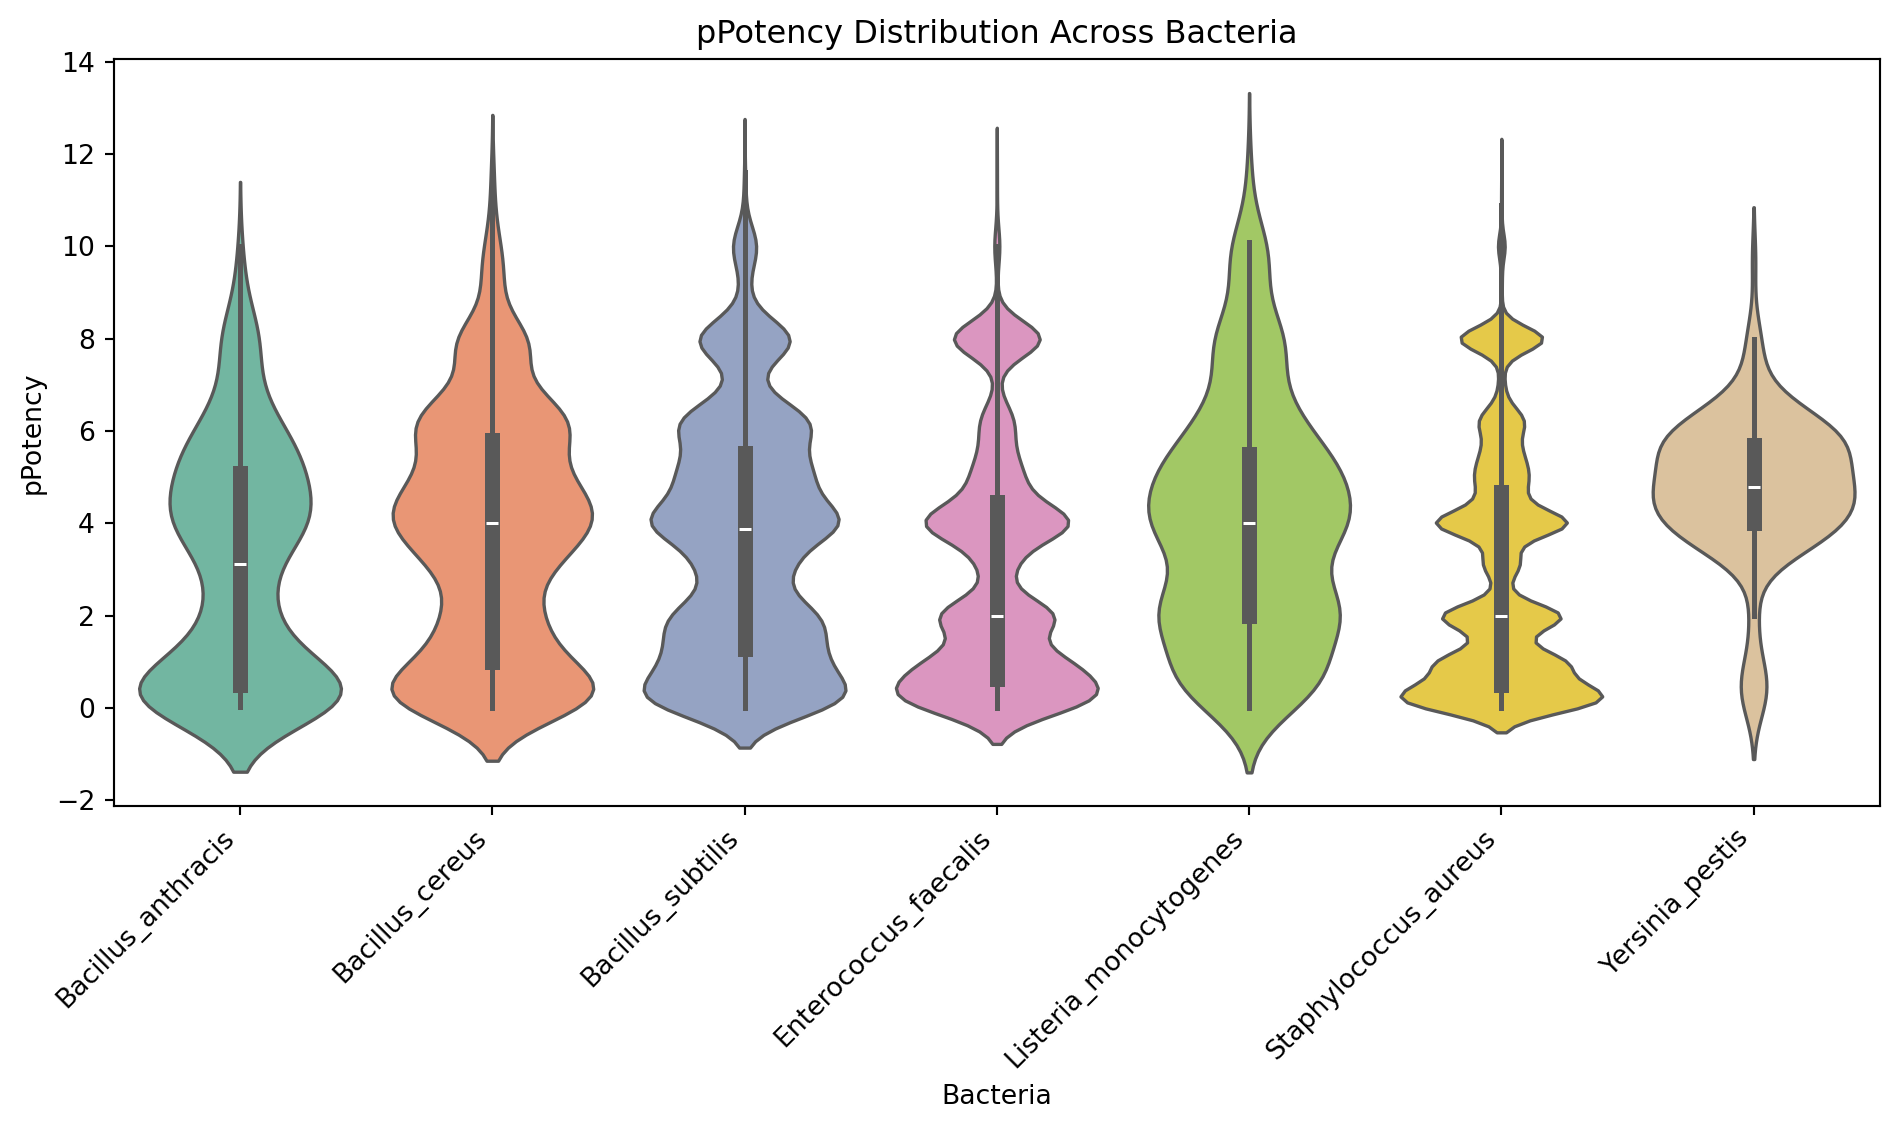

In [64]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=allBacteriaData_chEMBL_ordered,
    x='BacteriaClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

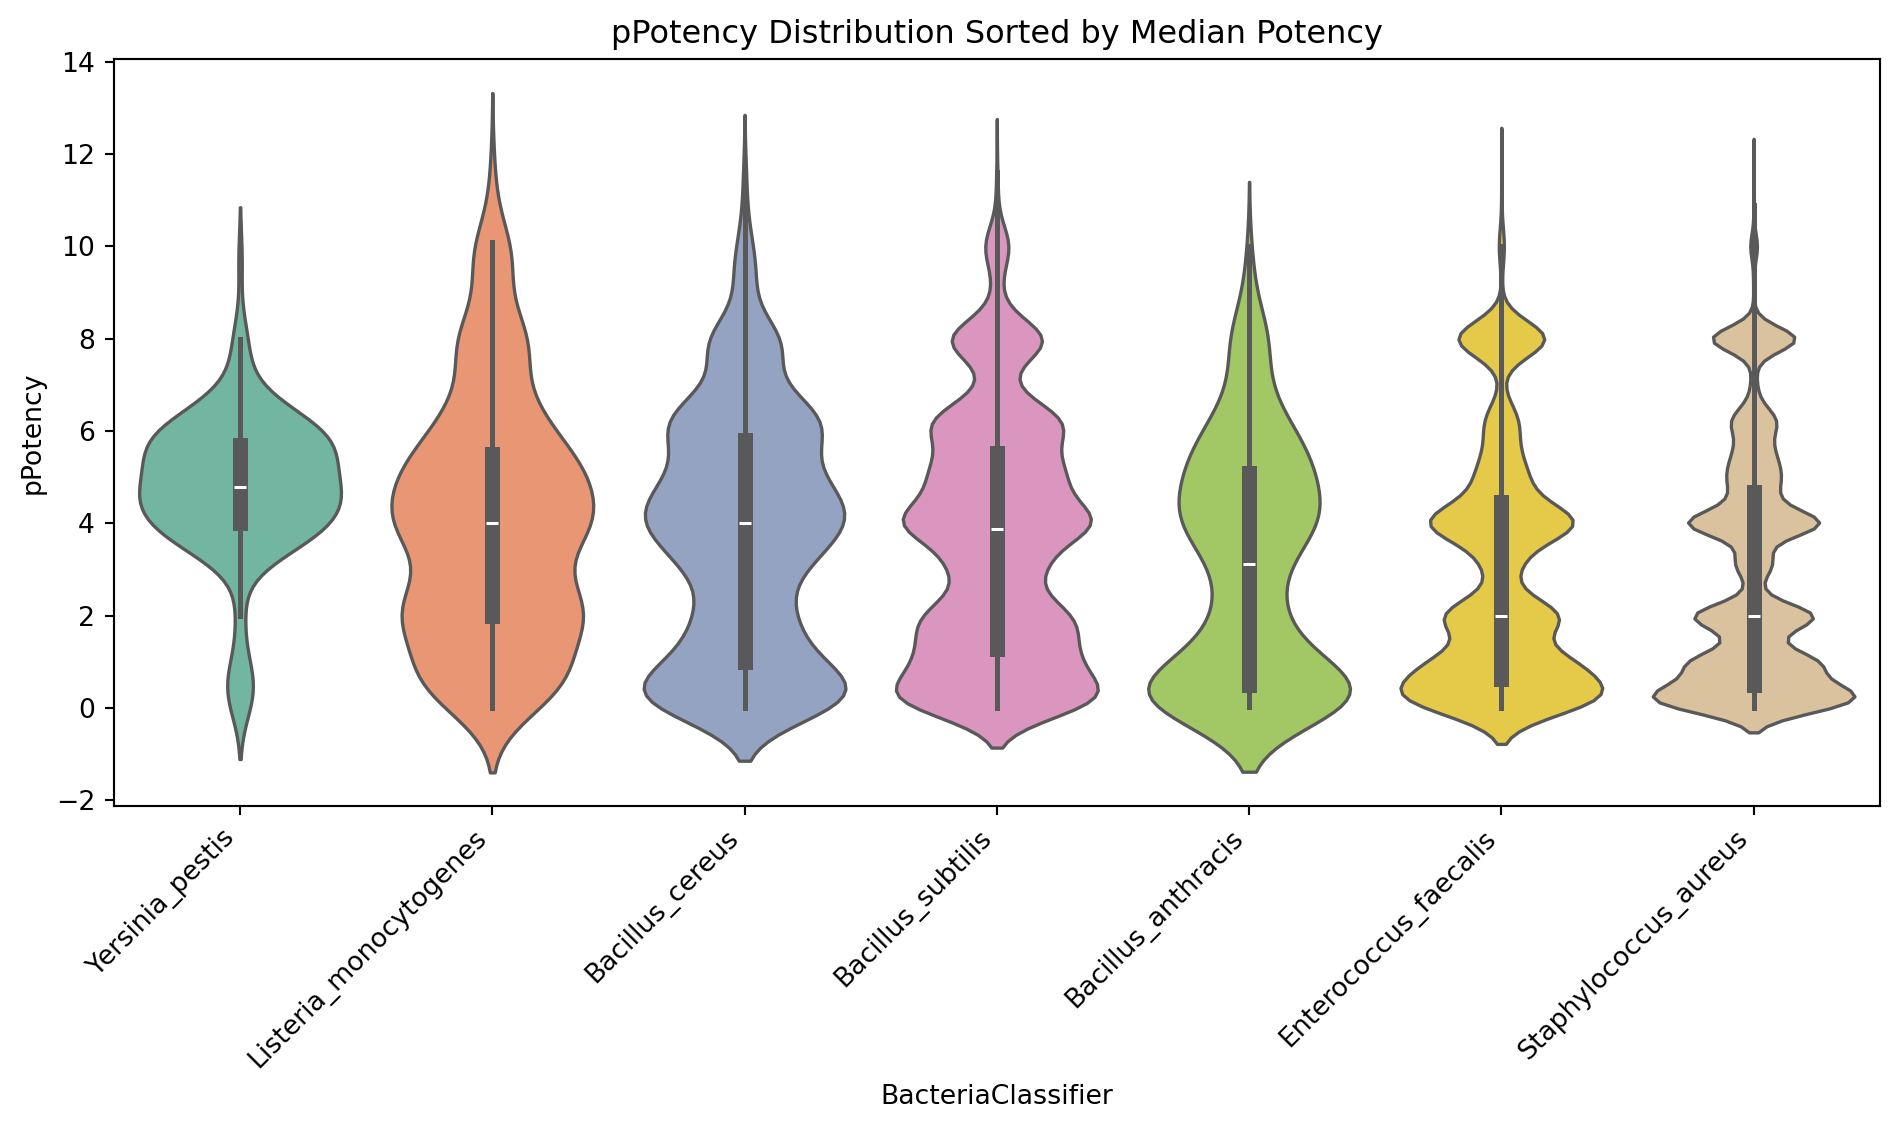

In [65]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=allBacteriaData_chEMBL_ordered,
    x='BacteriaClassifier',
    y='pPotency',
    palette='Set2',
    order=(
        allBacteriaData_chEMBL_ordered
        .groupby('BacteriaClassifier')['pPotency']
        .median()
        .sort_values(ascending=False)
        .index
    )
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Sorted by Median Potency')
plt.tight_layout()
plt.show()

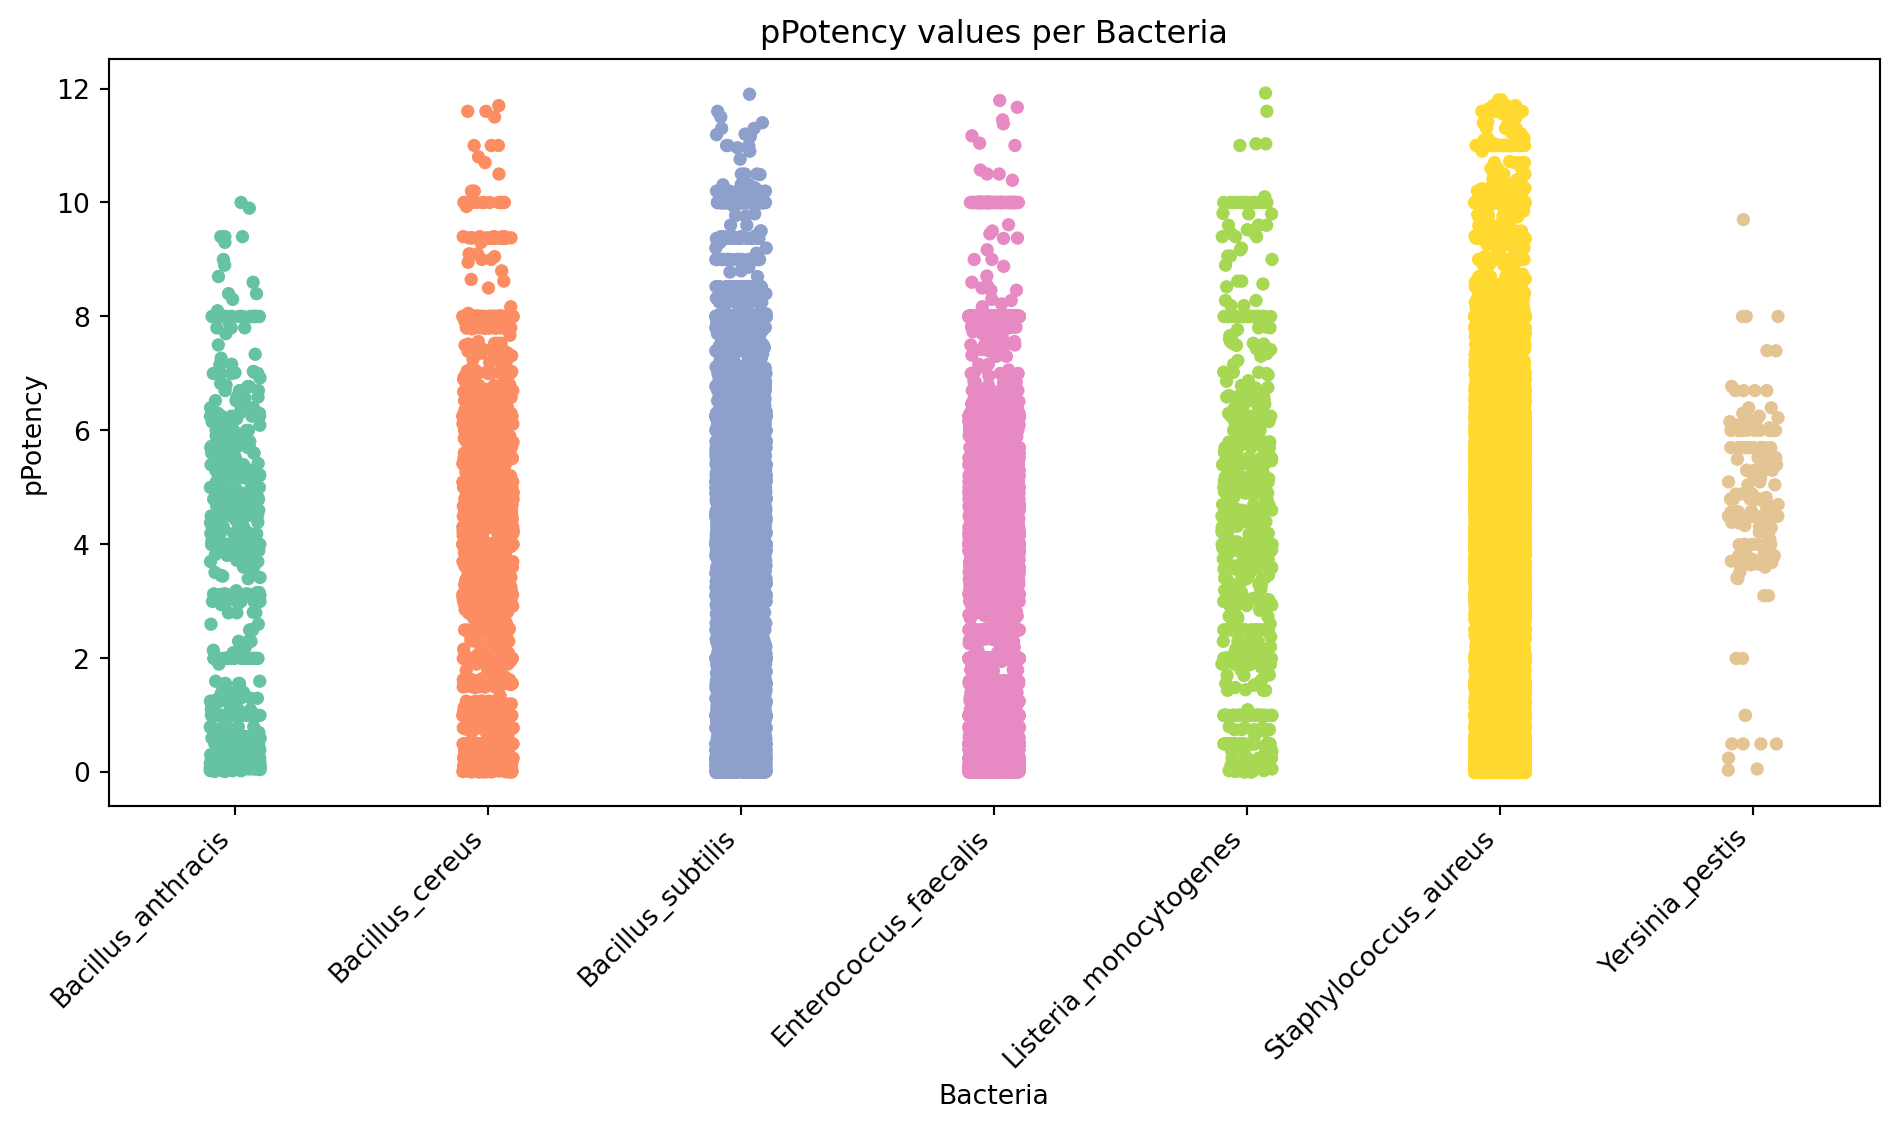

In [66]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=allBacteriaData_chEMBL_ordered,
    x='BacteriaClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [144]:
# df = allBacteriaData_chEMBL
Y = allBacteriaData_chEMBL.pPotency
smiles = allBacteriaData_chEMBL.Smiles

In [145]:
print(len(smiles))

116388


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

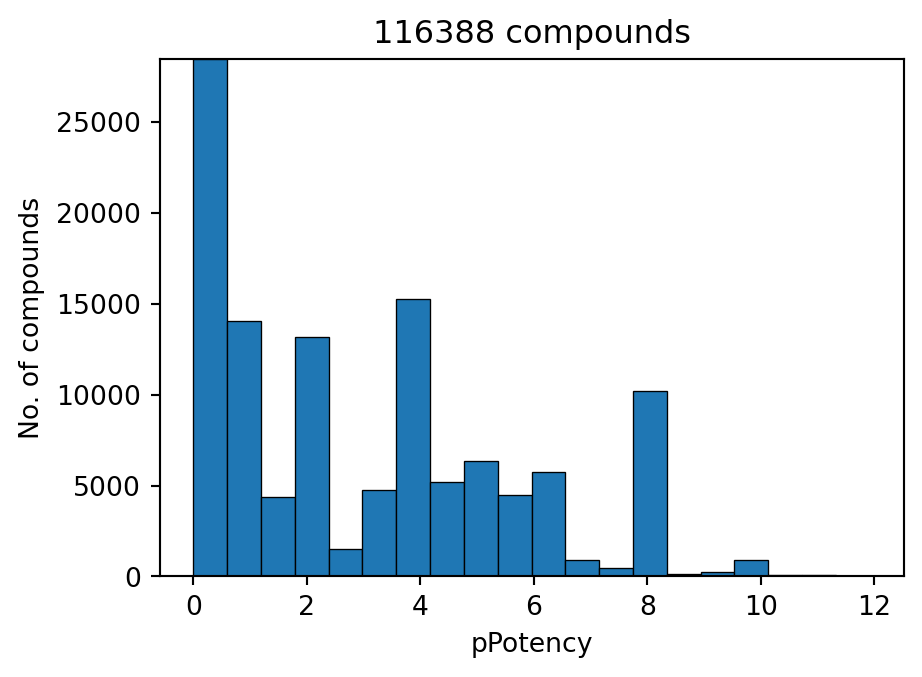

In [146]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [147]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [148]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [149]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=2000, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [150]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 116388 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

## Due to the huge size of the data set it is not possible to run ML models from jupyter notebook. Instead run them from console --> save the results in csv format --> then continue the analysis method as described below

1. start a screen session (optional): `screen -S macaw_env`
2. first switch to MACAW environment: `conda activate pubchemData`
3. run this command: `python Step4_bacteria_MLmodelComparison.py --n_folds 10 --n_jobs 4 --random_state 42`

In [ ]:
commandLineData_train = pd.read_csv( resultsDir + 'bacteriaCommandline_10fold/wDuplicates_predictions_train_SVR.csv')
Y_obs_train = commandLineData_train['Observed'].values
Y_cv_pred_train = commandLineData_train['Predicted'].values

In [ ]:
commandLineData_test = pd.read_csv( resultsDir + 'bacteriaCommandline_10fold/wDuplicates_predictions_test_SVR.csv')
Y_obs_test = commandLineData_test['Observed'].values
Y_cv_pred_test = commandLineData_test['Predicted'].values

In [ ]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Bacteria/allBacteria_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibacterialsData.shape}")

smiles_train = allBacteriaData_chEMBL.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibacterialsData['Canonical_SMILES'] = EnamineAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibacterialsData_filtered = EnamineAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibacterialsData = EnamineAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibacterialsData.shape}")
print(f"Removed {EnamineAntibacterialsData.shape[0] - EnamineAntibacterialsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntibacterialsData.head()

Load pre-trained models

In [ ]:
from joblib import load

print("Loading trained models")
regr_file_path = resultsDir + 'bacteriaCommandline_10fold/wDuplicates_SVR_regr_pred.joblib'
macaw_file_path = resultsDir + 'bacteriaCommandline_10fold/wDuplicates_SVR_macaw_model.joblib'

regr_pred = load(regr_file_path)
mcw = load(macaw_file_path)
print(f"Loaded: {regr_file_path}")
print(f"Loaded: {macaw_file_path}")

Fit the data with pretrained macaw model

In [ ]:
mcw.fit(smiles, Y)

Generate MACAW embeddings

In [ ]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")

Predict pPotency

In [ ]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Add predictions to dataframe

In [ ]:
EnamineAntibacterialsData_predicted = EnamineAntibacterialsData.copy()
EnamineAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibacterialsData_predicted['pPotency_prediction'])

EnamineAntibacterialsData_predicted = EnamineAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntibacterialsData_predicted

Let us represent the predictions of both models:

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_enamine_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_enamine_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntibacterialsData_final = EnamineAntibacterialsData.iloc[idx].copy()
EnamineAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibacterialsData_final

Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_top20

In [ ]:
EnamineAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = resultsDir + 'Bacteria/allBacteria_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = resultsDir + 'Bacteria/allBacteria_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to this bacteria (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibacterialsData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibacterialsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibacterialsData['Canonical_SMILES'] = LCAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
LCAntibacterialsData_filtered = LCAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
LCAntibacterialsData = LCAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibacterialsData.shape}")
print(f"Removed {LCAntibacterialsData_filtered.shape[0] - LCAntibacterialsData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntibacterialsData.head()

In [ ]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")

In [ ]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

In [ ]:
LCAntibacterialsData_predicted = LCAntibacterialsData.copy()
LCAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-LCAntibacterialsData_predicted['pPotency_prediction'])

LCAntibacterialsData_predicted = LCAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_LCDatasets_predicted_all.csv"), index=False)
LCAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntibacterialsData_predicted

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
LCAntibacterialsData_final = LCAntibacterialsData.iloc[idx].copy()
LCAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibacterialsData_final = LCAntibacterialsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibacterialsData_final

### Top 20 compounds with higher pPPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibacterialsData_top20 = LCAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibacterialsData_top20 = LCAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_top20

In [ ]:
LCAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_LCAntiviralsData_top20.csv"), index=False)
LCAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_LCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = resultsDir + 'Bacteria/allBacteria_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = resultsDir + 'Bacteria/allBacteria_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all viruses (data source ChemDiv antibiotics)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library ("ChemDiv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiBioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiBioticData

In [ ]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")

In [ ]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

In [ ]:
ChemDivAntiBioticData_predicted = ChemDivAntiBioticData.copy()
ChemDivAntiBioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiBioticData_predicted['IC50 (M)'] = 10 ** (-ChemDivAntiBioticData_predicted['pPotency_prediction'])

ChemDivAntiBioticData_predicted = ChemDivAntiBioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)

ChemDivAntiBioticData_predicted.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiBioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiBioticData_predicted

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validationChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validationChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
ChemDivAntiBioticData_final = ChemDivAntiBioticData.iloc[idx].copy()
ChemDivAntiBioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiBioticData_final = ChemDivAntiBioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiBioticData_final

### Top 20 compounds with higher pPPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiBioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiBioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiBioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_top20

In [ ]:
ChemDivAntiBioticData_top20.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiBioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiBioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = resultsDir + 'Bacteria/allBacteria_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = resultsDir + 'Bacteria/allBacteria_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

# Now we will remove duplicate `SMILES` from training data and re-train the model

In [93]:
allBacteriaData_chEMBL.columns

Index(['ID', 'compound_id', 'Smiles', 'pPotency', 'BacteriaClassifier'], dtype='object')

In [94]:
# Print shape before removing duplicates
print("Before removing duplicates:", allBacteriaData_chEMBL.shape)

# Aggregate duplicates *within the same bacteria*
aggDF = (
    allBacteriaData_chEMBL.groupby(['Smiles', 'BacteriaClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
allBacteriaData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'BacteriaClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'BacteriaClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", allBacteriaData_chEMBL_noDuplicates.shape)

Before removing duplicates: (116388, 5)
After removing duplicates: (52264, 3)


In [95]:
allBacteriaData_chEMBL_noDuplicates.columns

Index(['Smiles', 'BacteriaClassifier', 'pPotency'], dtype='object')

In [96]:
duplicates = allBacteriaData_chEMBL_noDuplicates.duplicated(subset=['Smiles', 'BacteriaClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


In [97]:
allBacteriaData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "allBacteriaData_chEMBL_noDuplicates_MLready.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [98]:
# df = allBacteriaData_chEMBL_noDuplicates
Y = allBacteriaData_chEMBL_noDuplicates.pPotency
smiles = allBacteriaData_chEMBL_noDuplicates.Smiles

In [99]:
print(len(smiles))

52264


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

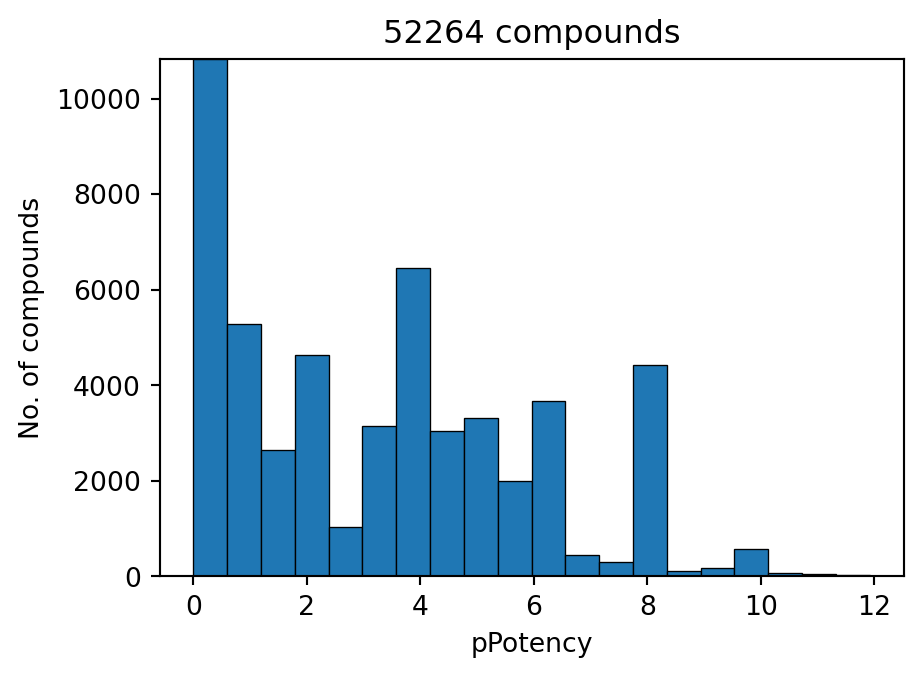

In [100]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [101]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [102]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [103]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=2000, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [104]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 52264 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Due to the huge size of the data set it is not possible to run ML models from jupyter notebook. Instead run them from console --> save the results in csv format --> then continue the analysis method as described below

1. start a screen session (optional): `screen -S macaw_env`
2. first switch to MACAW environment: `conda activate pubchemData`
3. run this command: `python Step4_bacteria_MLmodelComparison_noDuplicates.py --n_folds 10 --n_jobs 4 --random_state 42`

In [105]:
commandLineData_train = pd.read_csv( resultsDir + 'bacteriaCommandline_10fold/noDuplicates_predictions_train_SVR.csv')
Y_obs_train = commandLineData_train['Observed'].values
Y_cv_pred_train = commandLineData_train['Predicted'].values

In [106]:
commandLineData_test = pd.read_csv( resultsDir + 'bacteriaCommandline_10fold/noDuplicates_predictions_test_SVR.csv')
Y_obs_test = commandLineData_test['Observed'].values
Y_cv_pred_test = commandLineData_test['Predicted'].values

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_CV_TrTs.png


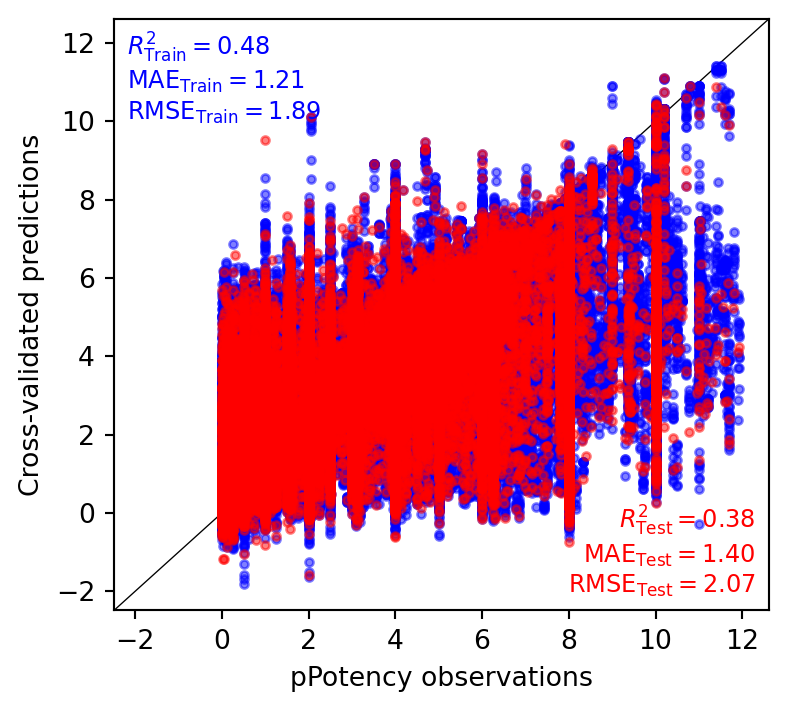

In [107]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Bacteria/allBacteria_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [108]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibacterialsData.shape}")

smiles_train = allBacteriaData_chEMBL_noDuplicates.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibacterialsData['Canonical_SMILES'] = EnamineAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibacterialsData_filtered = EnamineAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibacterialsData = EnamineAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibacterialsData.shape}")
print(f"Removed {EnamineAntibacterialsData.shape[0] - EnamineAntibacterialsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntibacterialsData.head()

Original Enamine data shape: (32000, 11)
Number of unique SMILES in training set: 36826
Filtered Enamine data shape for validation: (31995, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 31995


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.60,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.50,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.01,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.70,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.70,4,https://real.enamine.net/public-enum-files/Z15...


Load pre-trained models

In [110]:
from joblib import load

print("Loading trained models")
regr_file_path = resultsDir + 'bacteriaCommandline_10fold/noDuplicates_SVR_regr_pred.joblib'
macaw_file_path = resultsDir + 'bacteriaCommandline_10fold/noDuplicates_SVR_macaw_model.joblib'

regr_pred = load(regr_file_path)
mcw = load(macaw_file_path)
print(f"Loaded: {regr_file_path}")
print(f"Loaded: {macaw_file_path}")

Loading trained models
Loaded: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/bacteriaCommandline_10fold/noDuplicates_SVR_regr_pred.joblib
Loaded: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/bacteriaCommandline_10fold/noDuplicates_SVR_macaw_model.joblib


Fit the data with pretrained macaw model

In [111]:
mcw.fit(smiles, Y)

Generate MACAW embeddings

In [112]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (31995, 45)


Predict pPotency

In [113]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (31995,)


Add predictions to dataframe

In [114]:
EnamineAntibacterialsData_predicted = EnamineAntibacterialsData.copy()
EnamineAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibacterialsData_predicted['pPotency_prediction'])

EnamineAntibacterialsData_predicted = EnamineAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,4.022154,9.502687e-05
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,3.640246,2.289569e-04
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,1.228245,5.912285e-02
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,3.450991,3.540048e-04
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,6.270096,5.369136e-07
...,...,...,...
31995,CCOCCCOC(=O)C1=CC(=C(C)S1)[N+]([O-])=O,2.720003,1.905449e-03
31996,CC(C)C(NS(=O)(=O)CC12CCC(CC1=O)C2(C)C)C(N)=O,4.484224,3.279260e-05
31997,CNC(=O)CN1CCC(CC1)NS(=O)(=O)CCCC(F)(F)F,4.741617,1.812939e-05
31998,CCOC(=O)NC1CCCN(C1)C(=O)C2=CC(=NN2C3CC3)C(F)(F)F,5.092561,8.080509e-06


Let us represent the predictions of both models:

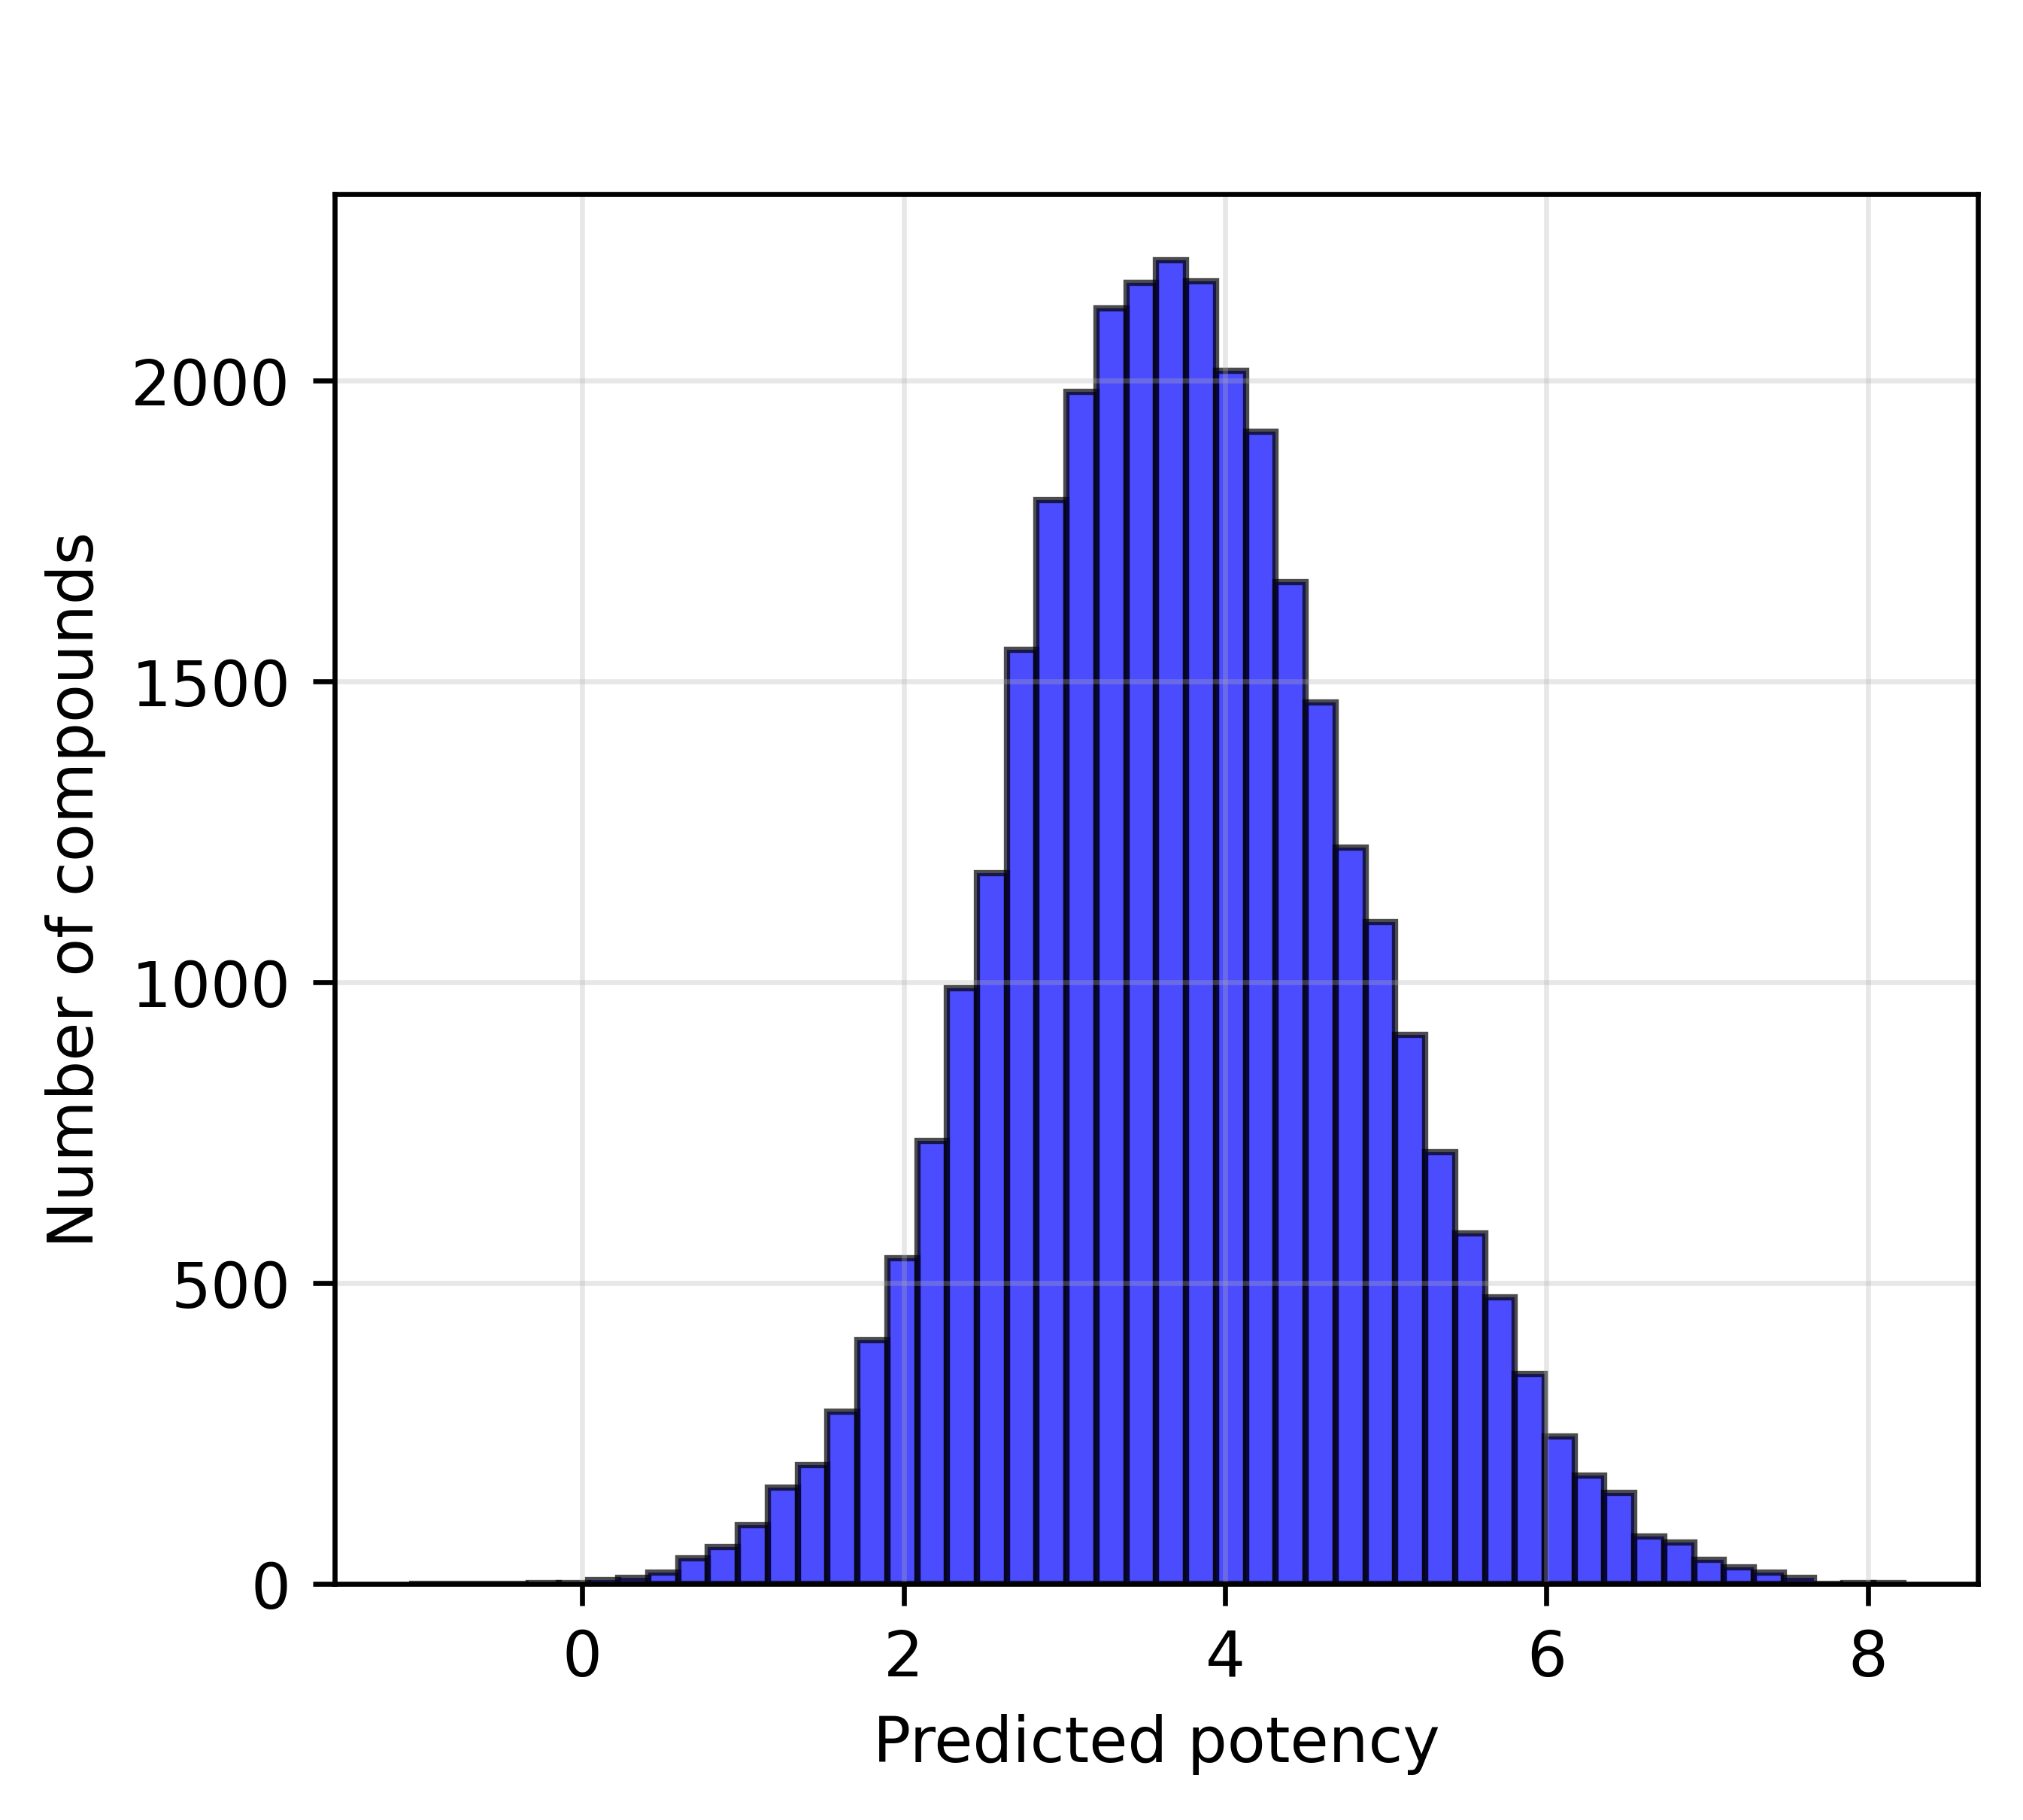

In [115]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_noDuplicates_enamine_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_noDuplicates_enamine_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [116]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 81 compounds
Medium priority (6 ≤ pPotency < 7.0): 739 compounds
Low priority (5 ≤ pPotency < 6): 3409 compounds


In [117]:
EnamineAntibacterialsData_final = EnamineAntibacterialsData.iloc[idx].copy()
EnamineAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibacterialsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction
108,CCOC(=O)C=1C=NC=2C=CC=CC2C1NCC=3C(C)=NOC3C,Z961112540,325.363,325.363,3.602,-2.938,1,4,77.25,6,https://real.enamine.net/public-enum-files/Z96...,7.198677
138,CCOC(=O)C1=CN(CC(N)=O)C=2C=C(C=CC2C1=O)C(F)(F)F,Z1203026981,342.271,342.271,0.414,-3.270,1,4,89.70,6,NaN,7.109610
457,NS(=O)(=O)C=1C=CC(=CC1)NC(=O)C=2C=CC(Cl)=C(C2)...,Z31413736,389.837,389.837,0.174,-4.030,3,5,149.42,4,https://real.enamine.net/public-enum-files/Z31...,7.467401
1221,[O-][N+](=O)C=1N=CN(CCOC(=O)C2=CC=3C=C(F)C=CC3...,Z1782089483,320.233,320.233,1.739,-4.950,0,5,113.29,6,https://real.enamine.net/public-enum-files/Z17...,7.265786
2867,Cl.CCOC(=O)C1=CC=CC(=C1)C2=CSC(=C2)CN,Z5379060339,297.802,261.341,3.141,-4.552,1,2,52.32,5,https://real.enamine.net/public-enum-files/Z53...,7.199812
...,...,...,...,...,...,...,...,...,...,...,...,...
29817,COC=1C=CC(O)=C(C1)C(C)NC(=O)C2=CC(=C(C)O2)S(N)...,Z1451171760,354.380,354.380,0.892,-2.659,3,5,131.86,6,https://real.enamine.net/public-enum-files/Z14...,7.326457
30041,COC(=O)NC=1C=CC(=CC1)NC(=O)NC(C)C(=O)NC(C)(C)C,Z975115736,336.387,336.387,1.185,-3.250,4,4,108.56,10,https://real.enamine.net/public-enum-files/Z97...,7.252414
30536,NC(=O)C(OC(=O)C=1C=CC=CC1[N+]([O-])=O)C=2C=CC=CC2,Z237943948,300.267,300.267,1.668,-4.444,1,4,112.53,6,https://real.enamine.net/public-enum-files/Z23...,7.324675
31431,COC(=O)NC(C)(C)C(=O)NC(C)C1=CC(OC)=C(C=C1F)OC,Z1204223295,342.363,342.363,1.661,-2.979,2,4,85.89,9,https://real.enamine.net/public-enum-files/Z12...,7.287729


Top 20 compounds with higher pPotency

In [118]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 7.45
Highest predicted pPotency: 8.22
Range of top 20: 7.45 - 8.22


In [119]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    7.449
  IC50:        3.554e-08 M  (35.54 nM)

Best Values (1st ranked compound):
  pPotency:    8.220
  IC50:        6.030e-09 M  (6.03 nM)

 Range for Top 20 Compounds:
pPotency Range:  7.449 - 8.220

IC50 Range (M):  3.554e-08 - 6.030e-09


,Rank,SMILES,pPotency_prediction,IC50 (M)
25138,1,CC1=CC=C(O1)S(=O)(=O)NC2=CC(=CC=C2OC(F)F)C(=O)O,8.220,6.030e-09
8978,2,NS(=O)(=O)C=1C=CC(C=2C=CC=C(C2)C(F)(F)F)=C(C1)...,8.201,6.294e-09
16587,3,CC=1C=C(C=CC1Br)N2C(=O)C(F)(F)C2C=3C=CC=C(F)C3,8.033,9.264e-09
27685,4,CN1C(=O)OC=2C(=CC=CC21)NS(=O)(=O)C=3C=CC=CC3S(...,7.940,1.148e-08
14391,5,O=C(O)C=1C=CC(=CC1)NS(=O)(=O)C=2C=CC(Cl)=C(Cl)C2,7.801,1.583e-08
3681,6,Cl.NCC1=CC=C(O1)C=2C=CC(=CC2)S(N)(=O)=O,7.656,2.207e-08
14528,7,CC1=C(SC2=NC(C)=NC(NCCC=3C=CC(=CC3)S(N)(=O)=O)...,7.640,2.291e-08
20051,8,CC1=NNC(NS(=O)(=O)C=2C=CC=C3C=NC=CC23)=C1C#N,7.627,2.360e-08
15388,9,O=C(CCN1C(=O)CNC1=O)NC=2C=CC(=CC2)NS(=O)(=O)C3...,7.595,2.544e-08
9444,10,CS(=O)(=O)NCCCNC(=O)NC=1C=CC=C(C1)N2CCNC2=O,7.590,2.568e-08


In [120]:
EnamineAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_enamine_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_enamine_predictedCompounds.svg


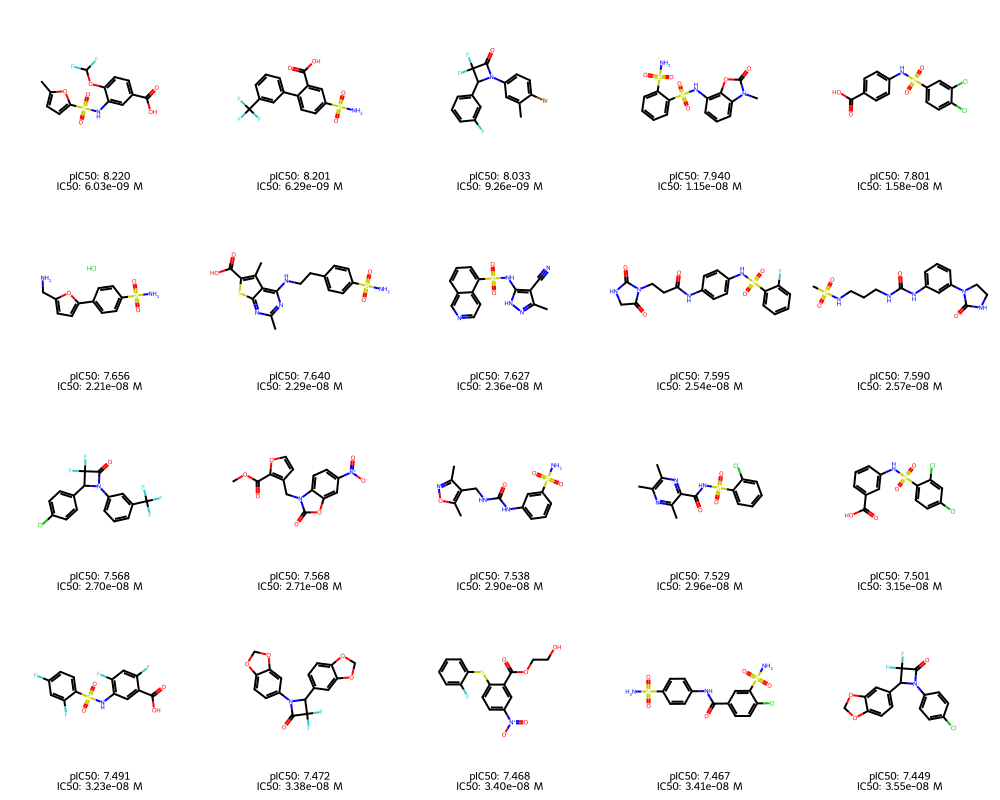

In [121]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = resultsDir + 'Bacteria/allBacteria_noDuplicates_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = resultsDir + 'Bacteria/allBacteria_noDuplicates_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to this bacteria (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [122]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibacterialsData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibacterialsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibacterialsData['Canonical_SMILES'] = LCAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
LCAntibacterialsData_filtered = LCAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
LCAntibacterialsData = LCAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibacterialsData.shape}")
print(f"Removed {LCAntibacterialsData_filtered.shape[0] - LCAntibacterialsData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntibacterialsData.head()

Original LifeChemicals data shape: (15538, 26)
Number of unique SMILES in training set: 36826
Filtered LifeChemicals data shape for validation: (15449, 26)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 15449


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Reference_ID,Activity_type,Activity_value_,Activity_units_,Activity_comment,Target_name,Target_organism,Target_type,SMILES,PPDS
0,F6540-4248,"6-(3-methoxypiperidin-1-yl)-N,N-dimethylpyrimi...",2097927-68-7,1.500,236.310,oil,0.670,1.600,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,COC1CCCN(c2cc(N(C)C)ncn2)C1,NaN
1,F6541-0830,"1-(5,6,7,8-tetrahydroquinazolin-4-yl)piperidin...",1541766-76-0,1.500,233.310,oil,0.690,1.510,49.250,3,...,CHEMBL4533334,Inhibition,26.560,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,OC1CCCN(c2ncnc3c2CCCC3)C1,NaN
2,F6541-5261,5-fluoro-2-[4-(propan-2-yl)piperazin-1-yl]pyri...,2034458-11-0,1.500,224.280,oil,0.640,1.460,32.260,3,...,CHEMBL4542429,Inhibition,25.160,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC(C)N1CCN(c2ncc(F)cn2)CC1,NaN
3,F6543-7286,"6-(2,6-dimethylmorpholin-4-yl)-N,N-dimethylpyr...",2034461-31-7,1.500,236.310,solid,0.670,1.830,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,NaN
4,F6570-1027,1-[6-(dimethylamino)pyrimidin-4-yl]piperidin-3-ol,1903487-65-9,1.500,222.280,solid,0.640,0.840,52.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CN(C)c1cc(N2CCCC(O)C2)ncn1,NaN


In [123]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (15449, 45)


In [124]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (15449,)


In [125]:
LCAntibacterialsData_predicted = LCAntibacterialsData.copy()
LCAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-LCAntibacterialsData_predicted['pPotency_prediction'])

LCAntibacterialsData_predicted = LCAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,3.528,2.965e-04
1,OC1CCCN(c2ncnc3c2CCCC3)C1,3.571,2.686e-04
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,3.777,1.669e-04
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,3.900,1.258e-04
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,2.968,1.077e-03
...,...,...,...
15533,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,2.460,3.466e-03
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,8.601,2.504e-09
15535,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,5.420,3.803e-06
15536,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,6.895,1.274e-07


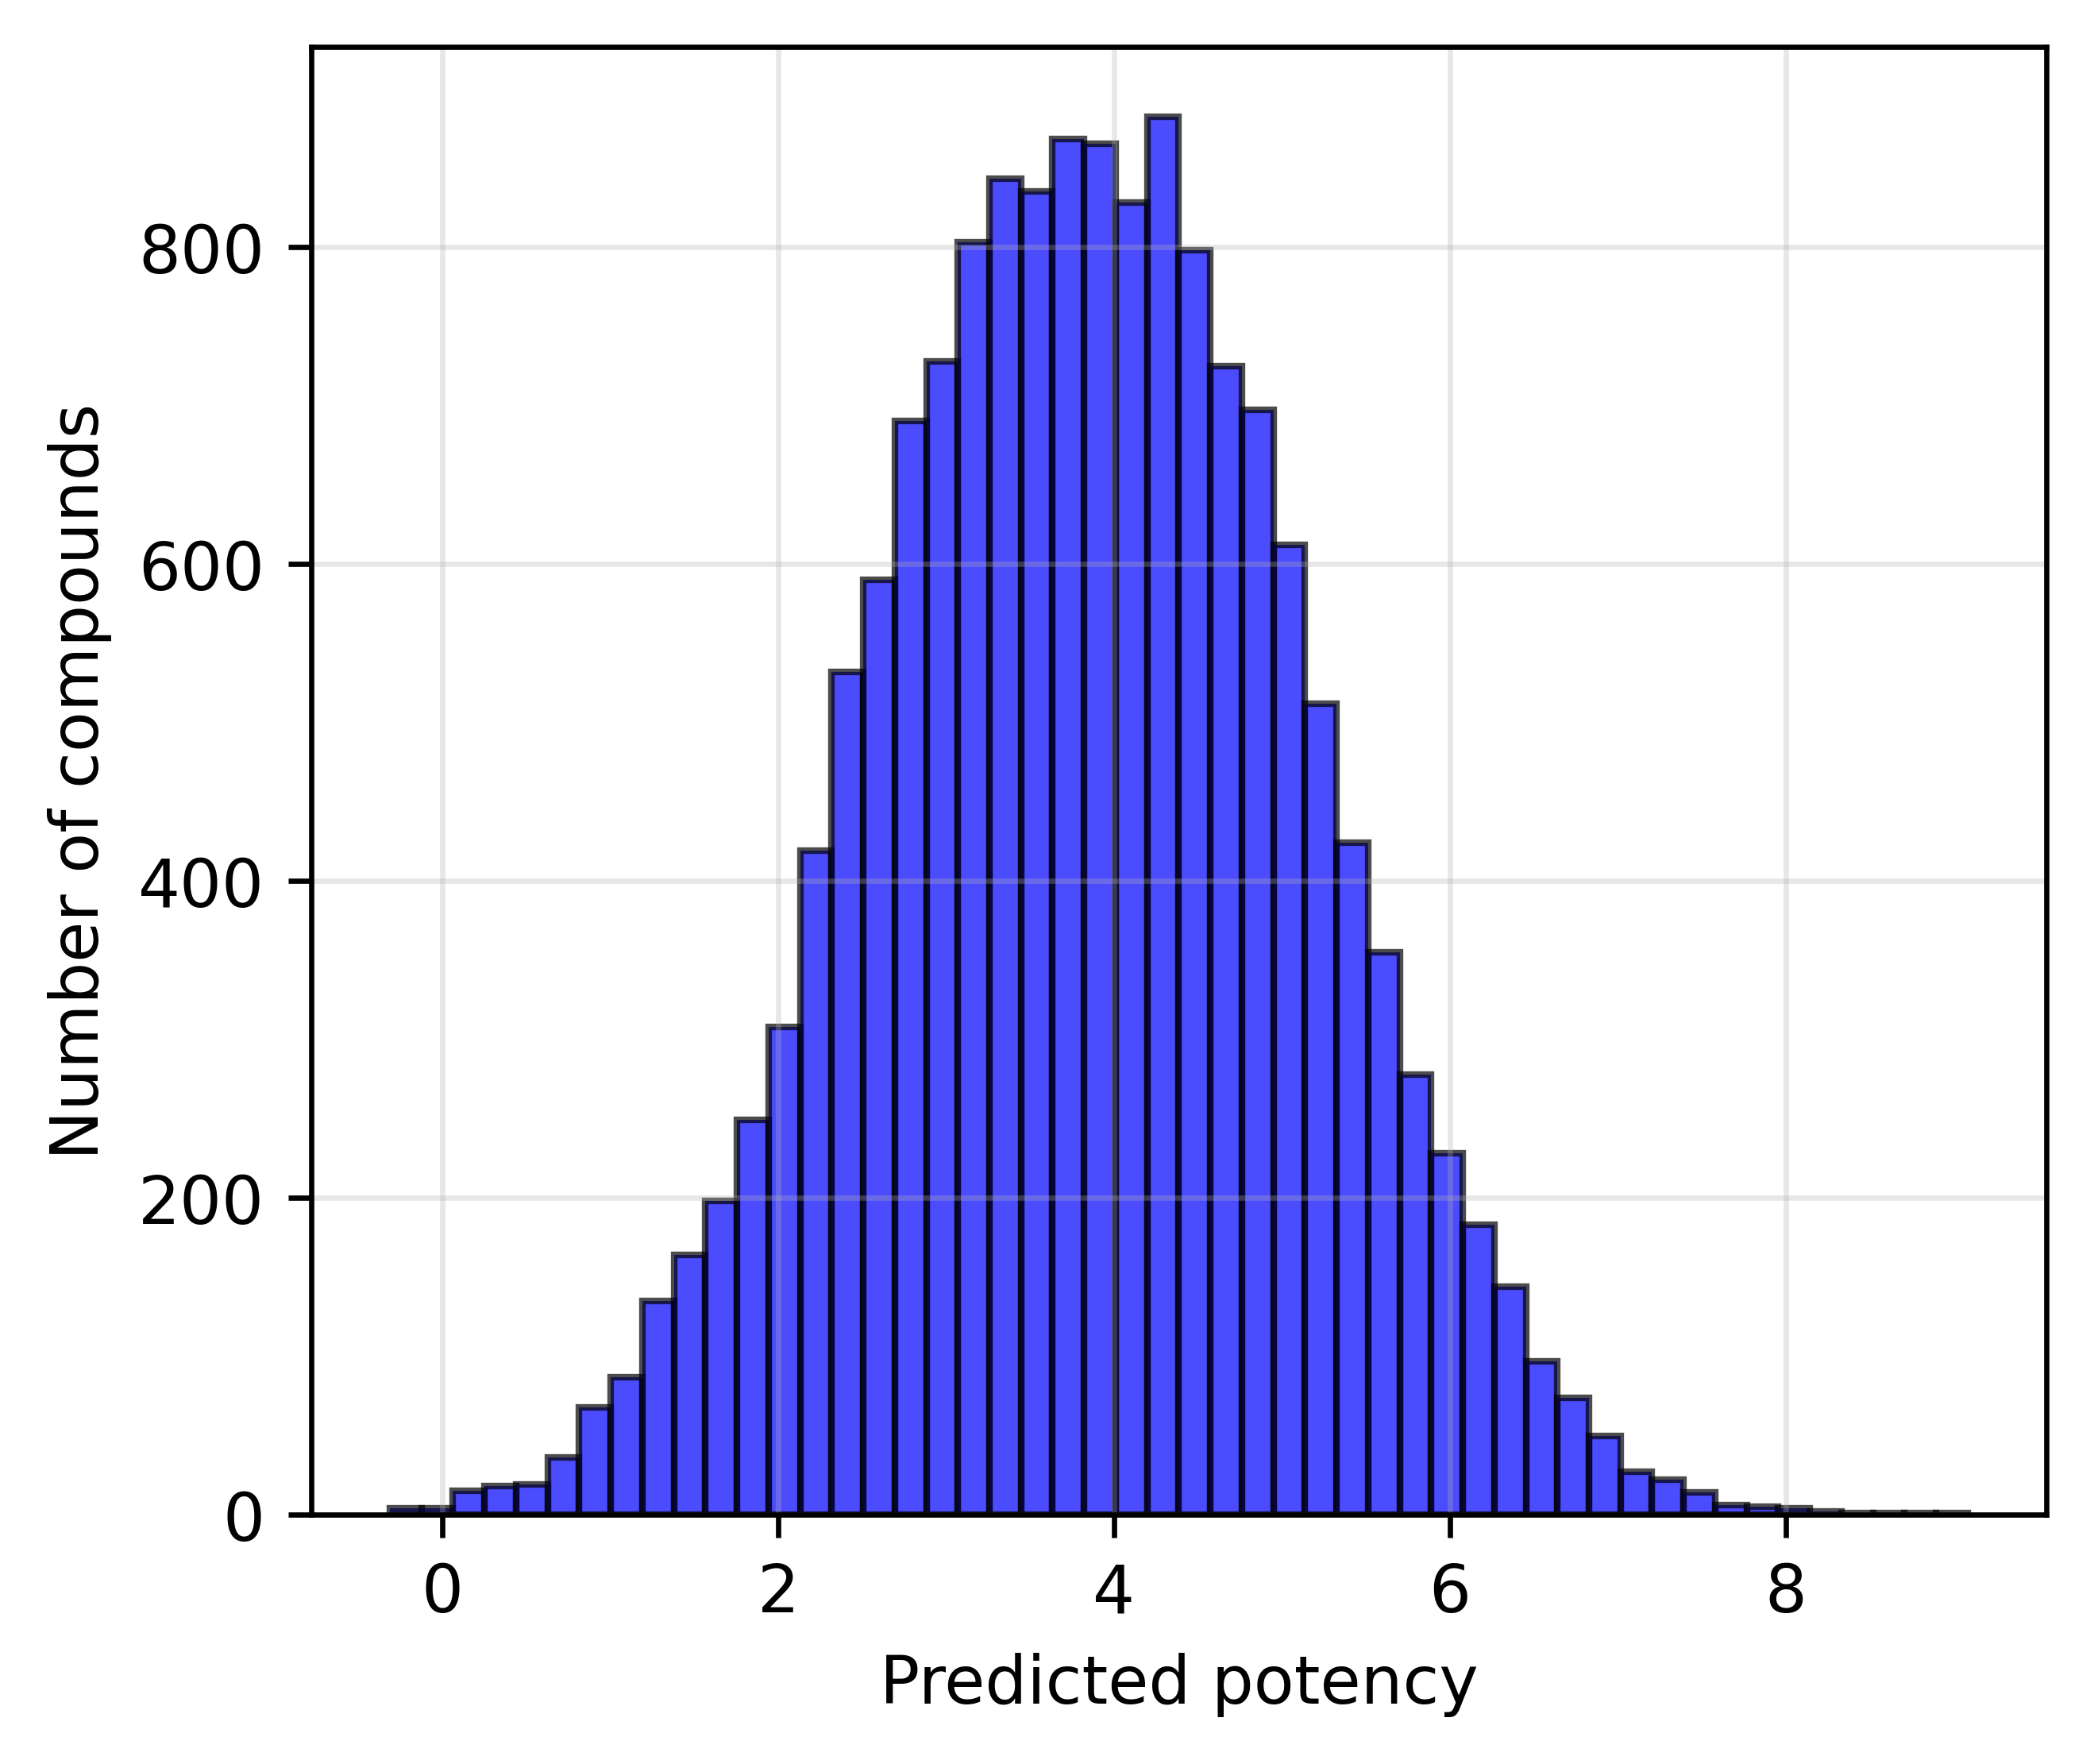

In [126]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_noDuplicates_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_noDuplicates_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [127]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 86 compounds
Medium priority (6 ≤ pPotency < 7.0): 647 compounds
Low priority (5 ≤ pPotency < 6): 2124 compounds


In [128]:
LCAntibacterialsData_final = LCAntibacterialsData.iloc[idx].copy()
LCAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibacterialsData_final = LCAntibacterialsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibacterialsData_final

,SMILES,pPotency_prediction,clogP
433,O=C(Nc1ccc(Br)cc1F)c1cc(N2CCOCC2)ncn1,7.236,2.100
1819,Cc1cc(NC(=O)c2cccc(Br)c2)n(-c2nc(C)c(C)c(=O)[n...,7.610,2.130
2530,CNS(=O)(=O)c1ccc(NC(=O)c2ccc(Br)o2)cc1,7.800,1.860
2719,Cc1ncn(CC(=O)Nc2ccc(Br)cc2F)c(=O)c1C,7.394,1.940
2764,CC(C)NS(=O)(=O)c1ccc(NC(=O)c2ccc(Br)o2)cc1,7.282,2.700
...,...,...,...
15439,COc1cc(/C=N/NC(=O)c2ccc(C(=O)N/N=C/c3ccc(O)c(O...,7.217,2.660
15440,O=C(/C=C/c1ccc([N+](=O)[O-])cc1)Nc1cccc(NC(=O)...,8.024,4.670
15528,Nc1c(C(=O)N2CCN(c3cc4c(cc3F)c(=O)c(C(=O)O)cn4C...,8.450,1.820
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,8.601,3.540


### Top 20 compounds with higher pPPotency

In [129]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 7.61
Highest predicted pPotency: 9.08
Range of top 20: 7.61 - 9.08


In [130]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibacterialsData_top20 = LCAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibacterialsData_top20 = LCAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    7.610
  IC50:        2.457e-08 M  (24.57 nM)

Best Values (1st ranked compound):
  pPotency:    9.084
  IC50:        8.248e-10 M  (0.82 nM)
Range for Top 20 Compounds:
pPotency Range:  7.610 - 9.084

IC50 Range (M):  2.457e-08 - 8.248e-10


,Rank,SMILES,pPotency_prediction,IC50 (M)
9876,1,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(Cc4nnc(-c5cc...,9.084,8.248e-10
14582,2,CCc1ccc(-n2nnc(C(=O)N3CCN(c4cc5c(cc4F)c(=O)c(C...,8.815,1.532e-09
15534,3,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,8.601,2.504e-09
15528,4,Nc1c(C(=O)N2CCN(c3cc4c(cc3F)c(=O)c(C(=O)O)cn4C...,8.450,3.549e-09
12947,5,CCOC(=O)c1c(-c2ccccc2)oc2ccc(O)cc12,8.211,6.155e-09
8279,6,CCOC(=O)c1c(-c2ccc(F)cc2)csc1N,8.190,6.452e-09
10801,7,Cl.N=c1ccc2c(-c3ccccc3C(=O)O)c3ccc(N)cc3oc-2c1,8.112,7.724e-09
15440,8,O=C(/C=C/c1ccc([N+](=O)[O-])cc1)Nc1cccc(NC(=O)...,8.024,9.467e-09
12282,9,Cc1ccc(C)c(S(=O)(=O)Nc2ccc(Cl)c(C(F)(F)F)c2)c1,8.008,9.809e-09
7955,10,CCOC(=O)c1c(-c2ccccc2)csc1N,7.970,1.070e-08


In [131]:
LCAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_predictedCompounds_LCDataset.svg


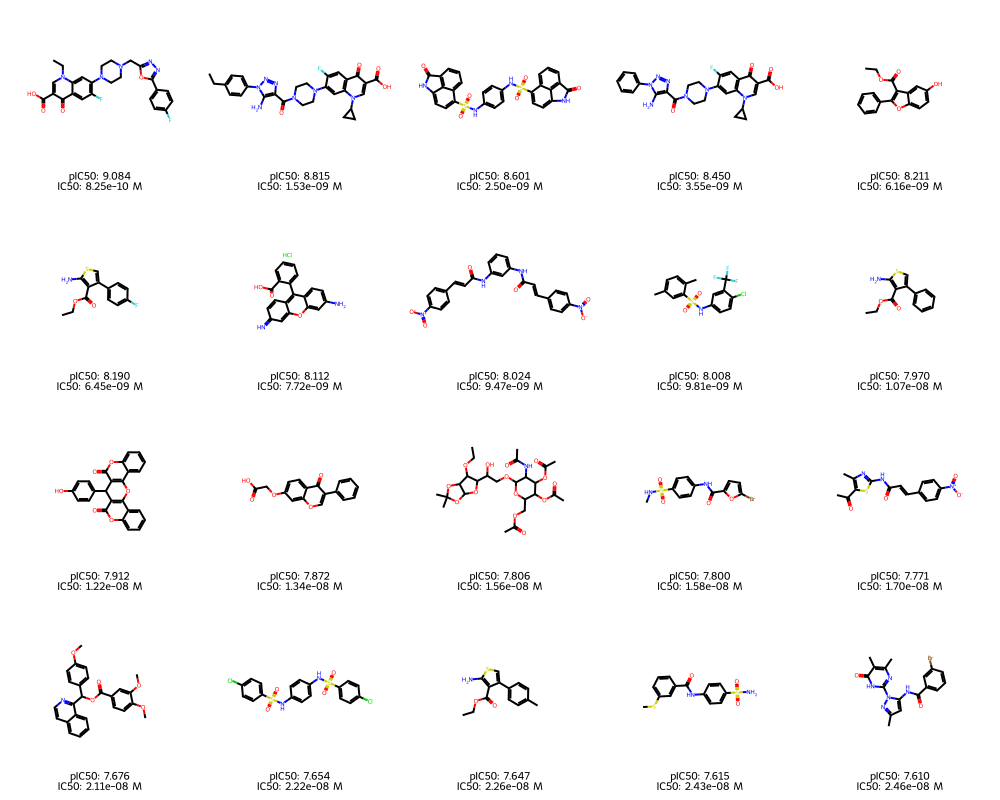

In [132]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = resultsDir + 'Bacteria/allBacteria_noDuplicates_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = resultsDir + 'Bacteria/allBacteria_noDuplicates_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all viruses (data source ChemDiv antibiotics)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library ("ChemDiv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [133]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiBioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiBioticData

Original ChemDiv data shape: (12510, 16)
Number of unique SMILES in training set: 36826
Filtered ChemDiv data shape for validation: (12473, 16)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 12473


,IDNUMBER,STEREO_COMMENTS,SMILE,LOGP,LOGD,LOGSW,N_ROTB,N_CHIRALS,H_ACCEPTORS,H_DONORS,PSA,WEIGHT_AVAILABLE1,CHEMNAME,SMILES,SALTDATA,SALTDATA_MOLWEIGHT
0,000L-0380,ACHIRAL,[O-][N+](c(cc1)ccc1C(Oc(cc1)ccc1-c1ccccc1)=O)=O,4.934,4.934,-5.149,5.000,0.000e+00,7.000,0.000e+00,53.726,34,"[1,1'-biphenyl]-4-yl 4-nitrobenzoate",O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,NaN,NaN
1,0071-0020,ACHIRAL,Cn(cc1)nc1C(N/N=C/c(cc1)ccc1OC)=O,1.256,1.255,-1.843,5.000,0.000e+00,5.000,1.000,57.790,12,N'-[(4-methoxyphenyl)methylidene]-1-methyl-1H-...,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,NaN,NaN
2,0080-0039,RACEMIC MIXTURE,CC1(C)OC1COC(c(cc(cco1)c1c1)c1O1)=CC1=O,2.481,2.481,-3.143,3.000,1.000,6.000,0.000e+00,44.076,113,"5-[(3,3-dimethyloxiran-2-yl)methoxy]-7H-furo[3...",CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,NaN,NaN
3,0083-0046,ACHIRAL,O=C(Cc1ccccc1)c(cc1)ccc1-c1ccccc1,4.779,4.779,-5.194,4.000,0.000e+00,2.000,0.000e+00,12.942,985,"1-([1,1'-biphenyl]-4-yl)-2-phenylethan-1-one",O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,NaN,NaN
4,0089-0027,ACHIRAL,O=C(c1cccc(C(Nc(cc2)ccc2Oc2ccccc2)=O)c1)Nc(cc1...,7.293,7.292,-6.294,10.000,0.000e+00,6.000,2.000,59.916,4,"N~1~,N~3~-bis(4-phenoxyphenyl)benzene-1,3-dica...",O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12505,Z601-8334,ACHIRAL,Nc1nc(Nc(cccc2)c2F)nc2ccccc12,3.415,3.097,-3.641,2.000,0.000e+00,2.000,3.000,48.570,460,"N~2~-(2-fluorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12506,Z601-8612,ACHIRAL,CNc1nc(Nc(cccc2)c2F)nc2ccccc12,4.019,3.229,-4.160,3.000,0.000e+00,2.000,2.000,39.170,841,N~2~-(2-fluorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12507,Z601-8674,ACHIRAL,Nc1nc(Nc(cccc2)c2Cl)nc2ccccc12,3.686,3.268,-3.905,2.000,0.000e+00,2.000,3.000,48.570,336,"N~2~-(2-chlorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2Cl)nc2ccccc12,NaN,NaN
12508,Z601-9100,ACHIRAL,CNc1nc(Nc(cccc2)c2Cl)nc2ccccc12,4.290,3.350,-4.279,3.000,0.000e+00,2.000,2.000,39.170,558,N~2~-(2-chlorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,HCl,36.461


In [134]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (12473, 45)


In [135]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (12473,)


In [136]:
ChemDivAntiBioticData_predicted = ChemDivAntiBioticData.copy()
ChemDivAntiBioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiBioticData_predicted['IC50 (M)'] = 10 ** (-ChemDivAntiBioticData_predicted['pPotency_prediction'])

ChemDivAntiBioticData_predicted = ChemDivAntiBioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)

ChemDivAntiBioticData_predicted.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiBioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiBioticData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,5.043,9.065e-06
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,4.762,1.729e-05
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,5.230,5.883e-06
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,5.529,2.959e-06
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,6.807,1.559e-07
...,...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,3.801,1.581e-04
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.917,1.209e-04
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.373,4.234e-05
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.020,9.560e-05


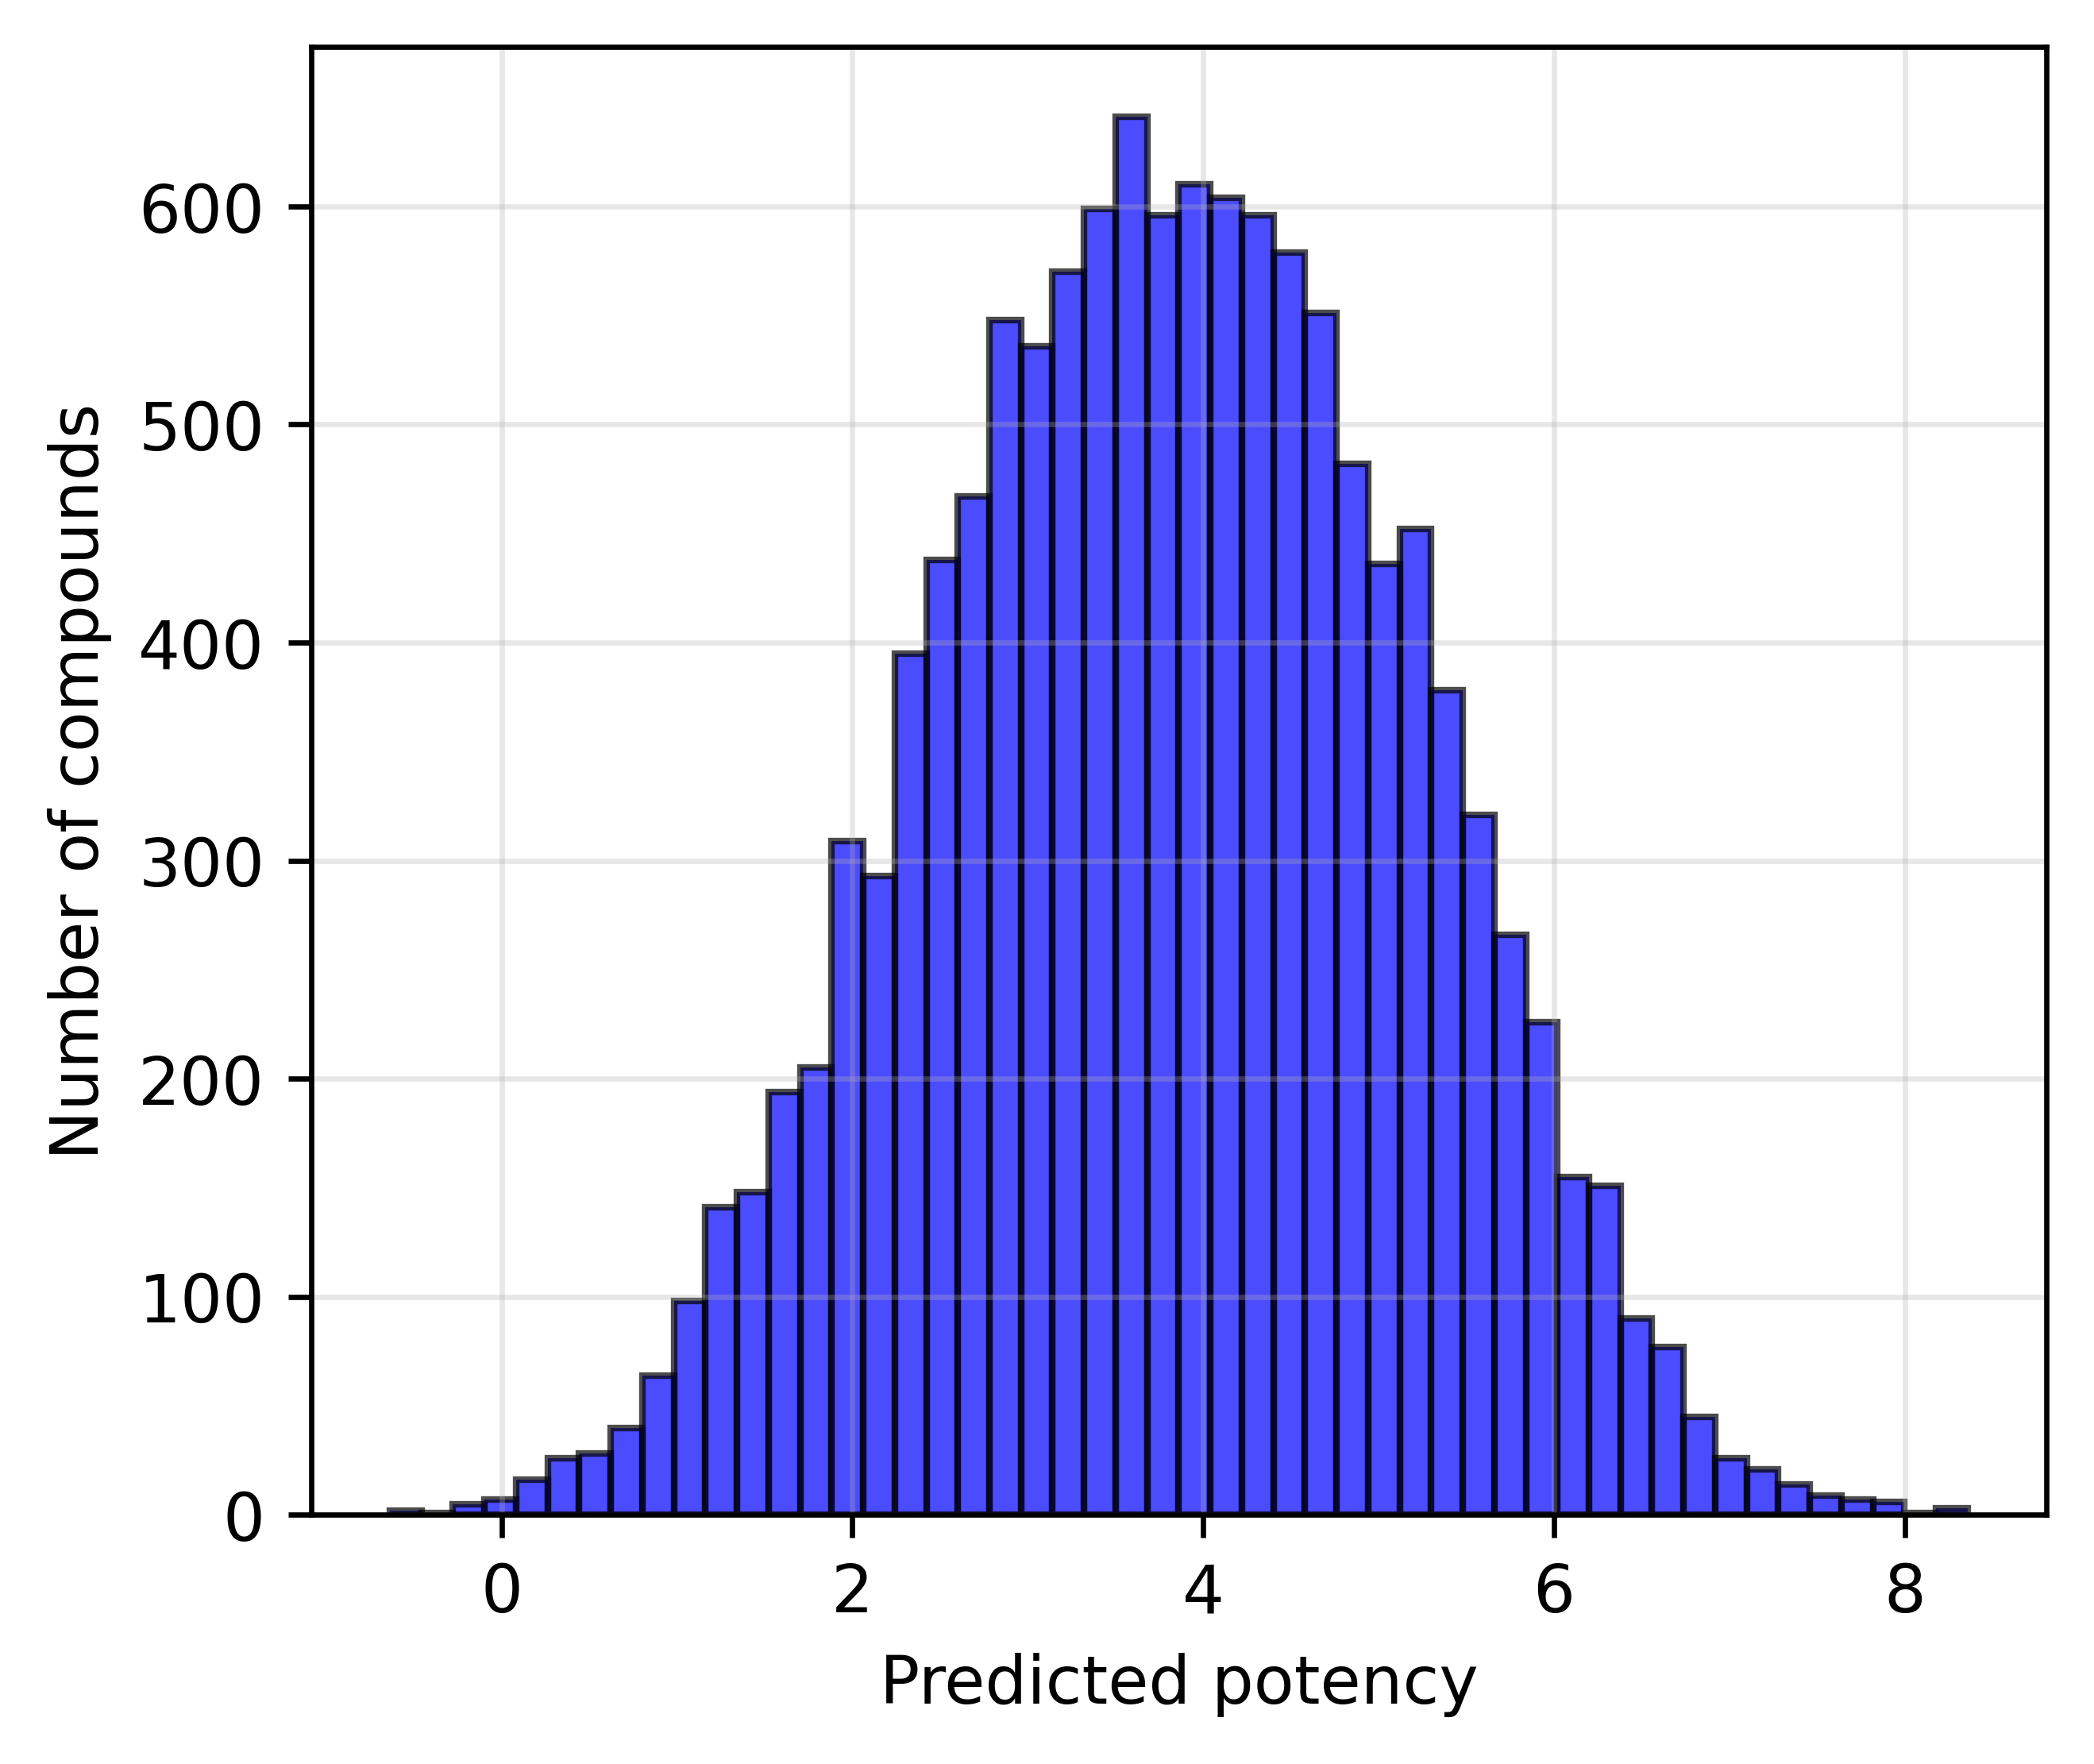

In [137]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_noDuplicates_validationChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_noDuplicates_validationChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [138]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 73 compounds
Medium priority (6 ≤ pPotency < 7.0): 547 compounds
Low priority (5 ≤ pPotency < 6): 1899 compounds


In [139]:
ChemDivAntiBioticData_final = ChemDivAntiBioticData.iloc[idx].copy()
ChemDivAntiBioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiBioticData_final = ChemDivAntiBioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiBioticData_final

,SMILES,pPotency_prediction
49,COCCCNc1cccc2c1C(=O)c1ccccc1C2=O,7.474
63,c1ccc(Cn2c3ccccc3c3ccccc32)cc1,7.438
70,CC(=O)Oc1ccc2c(c1)C(=O)c1ccccc1C2=O,7.068
144,Nc1ccc(C(=O)Nc2ccc(Oc3cccc(Oc4ccc(NC(=O)c5ccc(...,7.140
168,O=C(Nc1ccc(/N=C/c2ccccc2)cc1)c1cccc(C(=O)Nc2cc...,7.236
...,...,...
12389,Cc1csc(NC(=O)c2cccc(Br)c2)n1,7.167
12462,Cc1ccc(NS(=O)(=O)c2cccc3nonc23)cc1C,7.740
12465,Cc1cc(NS(=O)(=O)c2cccc3nonc23)ccc1Br,8.201
12466,Cc1cc(Br)ccc1NS(=O)(=O)c1cccc2nonc12,7.086


### Top 20 compounds with higher pPPotency

In [140]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 7.56
Highest predicted pPotency: 8.36
Range of top 20: 7.56 - 8.36


In [141]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiBioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiBioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiBioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    7.561
  IC50:        2.748e-08 M  (27.48 nM)

Best Values (1st ranked compound):
  pPotency:    8.358
  IC50:        4.382e-09 M  (4.38 nM)
Range for Top 20 Compounds:
pPotency Range:  7.561 - 8.358

IC50 Range (M):  2.748e-08 - 4.382e-09


,Rank,SMILES,pPotency_prediction,IC50 (M)
3332,1,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(C(=S)NC(=O)c...,8.358,4.382e-09
3331,2,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(C(=S)NC(=O)C...,8.222,5.996e-09
12465,3,Cc1cc(NS(=O)(=O)c2cccc3nonc23)ccc1Br,8.201,6.299e-09
3304,4,O=C1c2ccccc2C(=O)c2c(NCCCO)cccc21,8.063,8.648e-09
4576,5,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(C(=S)NC(=O)c...,7.927,1.183e-08
2990,6,O=C1NC(c2ccc(Cl)cc2)C(C(=O)c2ccc(Cl)cc2)C(O)(C...,7.905,1.243e-08
234,7,O=C(Nc1ccc(C(=O)Nc2ccc(NC(=O)c3ccc(NC(=O)c4ccc...,7.903,1.249e-08
4673,8,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(C(=S)NC(=O)c...,7.895,1.274e-08
9947,9,CCC(=O)Nc1nc2cc(NS(=O)(=O)c3ccc(Br)s3)ccc2s1,7.858,1.386e-08
2170,10,CCOC(=O)c1c2c(n3ccccc13)C(=O)c1ccccc1C2=O,7.826,1.493e-08


In [142]:
ChemDivAntiBioticData_top20.to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiBioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Bacteria/allBacteria_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_predictedCompounds_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacteria/allBacteria_noDuplicates_predictedCompounds_ChemDivDataset.svg


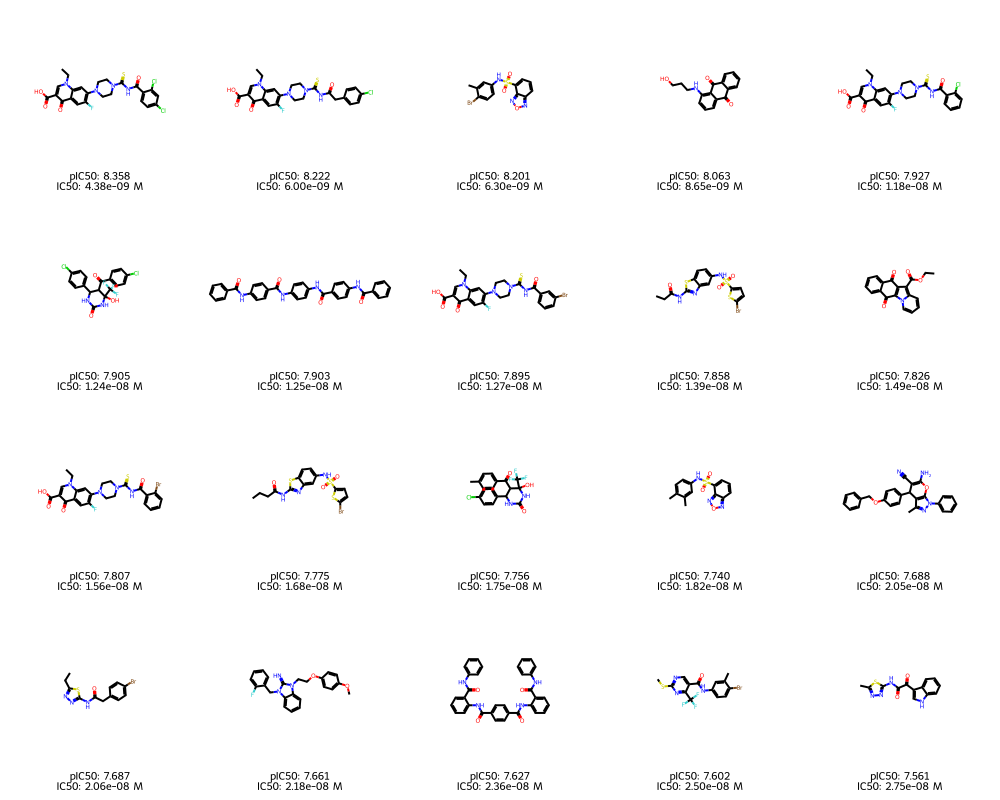

In [143]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiBioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = resultsDir + 'Bacteria/allBacteria_noDuplicates_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = resultsDir + 'Bacteria/allBacteria_noDuplicates_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

# Build feature matrix X and targets (regression + classification)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.svm import SVC
from sklearn.metrics import f1_score, balanced_accuracy_score
from copy import deepcopy

In [ ]:
yReg = allBacteriaData_chEMBL["pPotency"].to_numpy(dtype=np.float32)

labelEncoder = LabelEncoder()
yCls = labelEncoder.fit_transform(allBacteriaData_chEMBL["BacteriaClassifier"].astype(str).to_numpy())
BacteriaClasses = labelEncoder.classes_
print(f"[Info] Bacteria classes: {len(BacteriaClasses)}")

Train/valid split

In [ ]:
XTrain, XValid, yRegTrain, yRegValid, yClsTrain, yClsValid = train_test_split(
    XAll, yReg, yCls, test_size=0.2, random_state=42, stratify=yCls
)

Define the partitions for cross-validation.

In [ ]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [ ]:
param_grid_reg = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)

Regression

In [ ]:
smiles = allBacteriaData_chEMBL["Smiles"].astype(str).reset_index(drop=True)
Y = allBacteriaData_chEMBL["pPotency"].to_numpy(dtype=np.float32)

# Ensure smiles is a pandas Series
if isinstance(smiles, np.ndarray):
    smiles = pd.Series(smiles)
if isinstance(Y, np.ndarray):
    Y = pd.Series(Y)

# Drop NaN or missing targets
validMaskY = Y.notna() & ~Y.isnull()
smiles = smiles[validMaskY].reset_index(drop=True)
Y = Y[validMaskY].reset_index(drop=True)

# Validate SMILES strings
validIdx = []
for i, s in enumerate(smiles):
    if isinstance(s, str) and len(s) > 0 and Chem.MolFromSmiles(s) is not None:
        validIdx.append(i)

smiles = smiles.iloc[validIdx].reset_index(drop=True)
Y = Y.iloc[validIdx].reset_index(drop=True)

print(f" Cleaned data has: {len(smiles)} valid samples after dropping NaN targets and invalid SMILES.")
print(f"Example indices: {Y.index[:10].tolist()}")

In [ ]:
YcvPred = []
Yobs = []
bestParamsPerFold = []

foldId = 1
for trainIndex, valIndex in kf.split(smiles):
    print(f"Partition {foldId}/{kf.get_n_splits()}")
    foldId += 1

    smiTrain, smiVal = smiles.iloc[trainIndex], smiles.iloc[valIndex]
    yTrain, yVal = Y[trainIndex], Y[valIndex]

    # --- fit MACAW on TRAIN only (clone to avoid contaminating global mcw) ---
    mcwFold = deepcopy(mcw)
    mcwFold.fit(smiTrain, yTrain)

    XTrain = mcwFold.transform(smiTrain)
    XVal = mcwFold.transform(smiVal)

    # --- inner CV for SVR hyperparams on the TRAIN split ---
    grid = GridSearchCV(
        estimator=SVR(),
        param_grid=param_grid_reg,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        refit=True
    )
    grid.fit(XTrain, yTrain)
    bestParamsPerFold.append(grid.best_params_)

    # --- predict the validation split ---
    yPred = grid.predict(XVal)

    # accumulate
    YcvPred.extend(yPred)
    Yobs.extend(yVal)

### Evaluate cross validation performance

In [ ]:
mae = mean_absolute_error(Yobs, YcvPred)
r2 = r2_score(Yobs, YcvPred)
print(f"[Nested-CV Regression] MAE: {mae:.3f} | R2: {r2:.3f}")
print(f"[Info] Best params per fold (sample): {bestParamsPerFold[:3]}")

In [ ]:
# Parity plot
parity_plot(x=Yobs,
            y=YcvPred, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Bacteria/allBacteria_CV_Reg.svg',
            save_formats=['svg', 'png'])  # Specify both formats

### Generate a model trained on the whole data set, to be used for prediction tasks

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [ ]:
X_all = mcw.transform(smiles)
X_all.shape

In [ ]:
# Fit MACAW on ALL data 
mcwAll = deepcopy(mcw)
mcwAll.fit(smiles, Y)
XAll = mcwAll.transform(smiles)

# Hyperparameter search on ALL data (SVR with 5-fold CV), refit best on ALL
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

regrPred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_reg,  # same grid you defined earlier
    cv=5,
    refit=True,
    n_jobs=-1
)
regrPred.fit(XAll, Y)
print(f"[Refit-All] Best params: {regrPred.best_params_}")

# Train-set predictions and R² on ALL
yPredTrain = regrPred.predict(XAll)
print(f"[Refit-All] R^2 (train) = {r2_score(Y, yPredTrain):.2f}")

In [ ]:
# Parity plot
parity_plot(x=Y,
            y=yPredTrain, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Bacteria/allBacteria_allData_Reg.svg',
            save_formats=['svg', 'png'])  

# Classification: Cross Validation loop

In [ ]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

In [ ]:
# For classification we use SVC with RBF; only C is tuned here (gamma='scale' default)
param_grid_cls = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'kernel': ['rbf']
}

### Classification with Morgan (ECFP6) + RandomForest

In [ ]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Helpers
# ---------------------------
def morganBits(smilesList, nBits=2048, radius=3):
    """Return (X, validMask) where X is [n_valid, nBits] uint8 array of ECFP bits."""
    fps = []
    validMask = []
    for s in smilesList:
        mol = Chem.MolFromSmiles(s) if isinstance(s, str) else None
        if mol is None:
            validMask.append(False)
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=np.uint8)
        # NOTE: RDKit DataStructs is optional here; ConvertToNumpyArray handles directly if imported.
        # To avoid extra import, we iterate bits:
        onBits = list(fp.GetOnBits())
        arr[onBits] = 1
        fps.append(arr)
        validMask.append(True)
    if len(fps) == 0:
        return np.zeros((0, nBits), dtype=np.uint8), np.array(validMask, dtype=bool)
    return np.vstack(fps), np.array(validMask, dtype=bool)

def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# ---------------------------
# Prepare data
# ---------------------------
DF = allBacteriaData_chEMBL  
assert {"Smiles", "BacteriaClassifier"}.issubset(DF.columns), "Expected Smiles and BacteriaClassifier in DF."

smilesSeries = DF["Smiles"].astype(str).reset_index(drop=True)
labelsStr = DF["BacteriaClassifier"].astype(str).reset_index(drop=True)

# Encode string labels to ints (for modeling), but we will report strings
labelEncoder = LabelEncoder()
yEncAll = labelEncoder.fit_transform(labelsStr)

# Compute Morgan fingerprints and filter invalids
XAllBits, validMask = morganBits(smilesSeries.tolist(), nBits=2048, radius=3)
yEncAllValid = yEncAll[validMask]
labelsStrValid = labelsStr[validMask].reset_index(drop=True)

if XAllBits.shape[0] < 10:
    raise RuntimeError(f"Too few valid molecules after featurization: {XAllBits.shape[0]}")

print(f"[Info] Valid training molecules: {XAllBits.shape[0]} / {len(smilesSeries)}")

# ---------------------------
# Nested CV (outer stratified K-fold, inner grid search)
# ---------------------------
numOfPartitions = 10
kfOuter = StratifiedKFold(n_splits=numOfPartitions, shuffle=True, random_state=42)

paramGridCls = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]  # handle imbalance
}

YcvPredCls, YobsCls, bestParamsPerFold = [], [], []
foldId = 1
for trainIndex, valIndex in kfOuter.split(XAllBits, yEncAllValid):
    print(f"Partition {foldId}/{kfOuter.get_n_splits()}")
    foldId += 1

    XTrain, XVal = XAllBits[trainIndex], XAllBits[valIndex]
    yTrainEnc, yValEnc = yEncAllValid[trainIndex], yEncAllValid[valIndex]
    yValStr = labelEncoder.inverse_transform(yValEnc)

    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gridCls = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=paramGridCls,
        scoring="f1_macro",
        cv=inner,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gridCls.fit(XTrain, yTrainEnc)
    bestParamsPerFold.append(gridCls.best_params_)

    yPredEnc = gridCls.predict(XVal)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)

    YcvPredCls.extend(yPredStr.tolist())
    YobsCls.extend(yValStr.tolist())

### Cross Validation metrics

In [ ]:
f1Cv  = f1_score(YobsCls, YcvPredCls, average="macro")
baCv  = balanced_accuracy_score(YobsCls, YcvPredCls)
accCv = accuracy_score(YobsCls, YcvPredCls)
print(f"[Nested-CV] Classification | F1-macro: {f1Cv:.3f} | Balanced Acc: {baCv:.3f} | Acc: {accCv:.3f}")
print(f"[Info] Best params (sample): {bestParamsPerFold[:3]}")

### Cross Validation Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

yTrue = YobsCls   # true labels (strings)
yPred = YcvPredCls  # predicted labels (strings)

cm = confusion_matrix(yTrue, yPred, labels=np.unique(yTrue), normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yTrue))
disp.plot(xticks_rotation='vertical', cmap='Blues', values_format='.2f')
plt.title("Confusion Matrix (Validation Predictions)")
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Cross Validation Per-class precision/recall/F1 values

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(yTrue, yPred, output_dict=True)
reportDF = pd.DataFrame(report).T.iloc[:-3]  # remove avg rows
reportDF[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,4))
plt.title("Per-Class Precision/Recall/F1")
plt.ylabel("Score")
plt.ylim(0,1)
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_CV_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Refit on ALL valid data

In [ ]:
finalGrid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=paramGridCls,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True,
    verbose=0
)
finalGrid.fit(XAllBits, yEncAllValid)
finalCls = finalGrid.best_estimator_
print(f"[Refit-All] Best params: {finalGrid.best_params_}")

### In-sample metrics on ALL valid

In [ ]:
yAllPredEnc = finalCls.predict(XAllBits)
yAllPredStr = labelEncoder.inverse_transform(yAllPredEnc)
print(f"[Refit-All] F1-macro (train): {f1_score(labelsStrValid, yAllPredStr, average='macro'):.3f}")
print(f"[Refit-All] Balanced Acc (train): {balanced_accuracy_score(labelsStrValid, yAllPredStr):.3f}")
print(f"[Refit-All] Accuracy (train): {accuracy_score(labelsStrValid, yAllPredStr):.3f}")

### Confusion Matrix

In [ ]:
# --- Predictions on ALL (in-sample) ---
yPredEnc = finalCls.predict(XAllBits)

# Class labels (strings) for display
if 'labelEncoder' in globals():
    displayLabels = labelEncoder.classes_
    yTrueStr = labelEncoder.inverse_transform(yEncAllValid)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)
else:
    # fallback: show encoded ints if no encoder is available
    displayLabels = finalCls.classes_
    yTrueStr = yEncAllValid
    yPredStr = yPredEnc


cm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix (Train/All Data)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix (row-normalized by true class)
cm_norm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp_norm.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True, values_format=".2f")
ax.set_title("Confusion Matrix (Row-Normalized)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Per-class precision/recall/F1 values

In [ ]:
report = classification_report(yTrueStr, yPredStr, target_names=displayLabels, output_dict=True)
rep_df = pd.DataFrame(report).T.loc[displayLabels, ["precision", "recall", "f1-score"]]

ax = rep_df.plot(kind="bar", figsize=(10,4))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1 (Train/All Data)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_fullData_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

# Validation

In [ ]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

Keep SMILES as strings

In [ ]:
smi_enamine = EnamineAntiviralsData["Smiles"].astype(str).reset_index(drop=False)  # keeps 'index' column

Validate SMILES with RDKit

In [ ]:
valid_mask = smi_enamine["Smiles"].apply(lambda s: Chem.MolFromSmiles(s) is not None).to_numpy()
valid_rows = smi_enamine.loc[valid_mask, "index"].to_numpy()
smi_valid  = smi_enamine.loc[valid_mask, "Smiles"].tolist()

print(f"[Enamine] valid molecular smiles: {len(smi_valid)} / {len(smi_enamine)}")

Regression on pPotency data

In [ ]:
# MACAW features for Enamine (regression head)
X_enamine_reg = mcw.transform(smi_valid)

# Predict potency
Y_enamine_pred = regrPred.predict(X_enamine_reg)  # regrPred = best GridSearchCV or best estimator

Plot the results

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y_enamine_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validation_Reg.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Bacteria/allBacteria_validation_Reg.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y_enamine_pred >= 7)[0]
medium_priority_idx = np.where((Y_enamine_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y_enamine_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntiviralsData_final_Reg = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final_Reg['pPotency_prediction'] = Y_enamine_pred[idx]

EnamineAntiviralsData_final_Reg

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_Reg.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Classification task Enamine dataset

In [ ]:
from rdkit.Chem import AllChem

def morganBits(smilesList, nBits=2048, radius=3):
    X = np.zeros((len(smilesList), nBits), dtype=np.uint8)
    for i, s in enumerate(smilesList):
        m = Chem.MolFromSmiles(s)
        if m is None: 
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=radius, nBits=nBits)
        X[i, list(fp.GetOnBits())] = 1
    return X

X_enamine_cls = morganBits(smi_valid, nBits=2048, radius=3)

Predict class probabilities

In [ ]:
# Predict probabilities and top-1 / top-3
proba = finalCls.predict_proba(X_enamine_cls)       # [n_valid, n_classes]
top1 = np.argmax(proba, axis=1)

# classes as strings
classes_str = labelEncoder.classes_ if "labelEncoder" in globals() else finalCls.classes_
predBacteria_valid = classes_str[top1]
predBacteriaConf_valid = proba[np.arange(len(top1)), top1]

# Top-3 labels + probs (nice for triage)
top3_idx = np.argsort(-proba, axis=1)[:, :3]
predBacteriaTop3_valid = []
predBacteriaTop3Proba_valid = []
for r in range(top3_idx.shape[0]):
    labels3 = classes_str[top3_idx[r]]
    probs3 = [f"{labels3[j]}:{proba[r, top3_idx[r][j]]:.2f}" for j in range(len(labels3))]
    predBacteriaTop3_valid.append(", ".join(labels3))
    predBacteriaTop3Proba_valid.append(", ".join(probs3))


Assemble results in a table

In [ ]:
def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# Start with a copy of the valid subset rows
EnamineAntiviralsData_final_Cls = EnamineAntiviralsData.iloc[valid_rows].copy()

# Attach regression (potency)
safeInsert(EnamineAntiviralsData_final_Cls, 0, "pred_pPotency", np.round(Y_enamine_pred, 3))

# Attach classification (Bacteria)
safeInsert(EnamineAntiviralsData_final_Cls, 1, "predBacteria", predBacteria_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 2, "predBacteriaConf", np.round(predBacteriaConf_valid, 3))
safeInsert(EnamineAntiviralsData_final_Cls, 3, "predBacteriaTop3", predBacteriaTop3_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 4, "predBacteriaTop3Proba", predBacteriaTop3Proba_valid)

# Optional: composite rank for prioritization
alpha, beta = 1.0, 0.5
rankScore = alpha * EnamineAntiviralsData_final_Cls["pred_pPotency"].to_numpy() + \
            beta  * EnamineAntiviralsData_final_Cls["predBacteriaConf"].to_numpy()
safeInsert(EnamineAntiviralsData_final_Cls, 5, "rankScore", np.round(rankScore, 3))

print("[Enamine] final shape:", EnamineAntiviralsData_final_Cls.shape)
EnamineAntiviralsData_final_Cls.head()

Filter for pred_pPotency >= 7.0

In [ ]:
EnamineAntiviralsData_final_pPotency = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['pred_pPotency'] >= 7.0
]
EnamineAntiviralsData_final_pPotency

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_pPotency.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.0
 
 **rankScore=α×pred_pPotency+β×predBacteriaConf** (α = 1.0, β = 0.5)

* ≥ 7.5	--> Very promising (strong potency + good confidence)
* 7.0–7.5 -->	Potent hits, moderate confidence
* 6.0–7.0 -->	Potentially interesting, lower confidence or moderate potency
* < 6.0	--> Weak activity or uncertain classification

In [ ]:
EnamineAntiviralsData_final_rankScore = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.0
]
EnamineAntiviralsData_final_rankScore

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.5 (best predicted molecule)

In [ ]:
EnamineAntiviralsData_final_rankScore_best = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.5
]
EnamineAntiviralsData_final_rankScore_best

In [ ]:
EnamineAntiviralsData_final_rankScore_best.shape

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore_best.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Extract molecular properties of the best predicted drug molecule

In [ ]:
bestDrugMoleculeSMILES = EnamineAntiviralsData_final_rankScore_best["Smiles"]

smilesList = bestDrugMoleculeSMILES.tolist()
print(f"Number of top molecules: {len(smilesList)}")

Convert each SMILES to RDKit molecule objects

In [ ]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

mols = [Chem.MolFromSmiles(smi) for smi in smilesList if Chem.MolFromSmiles(smi) is not None]
print(f"Successfully parsed {len(mols)} valid molecules out of {len(smilesList)}")
bestDrugMoleculeSMILES = Chem.MolToSmiles(mol)

molProps = []
for i, mol in enumerate(mols):
    props = {
        "index": i,
        "SMILES": Chem.MolToSmiles(mol),
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "QED": Descriptors.qed(mol),
    }
    molProps.append(props)

molPropsDF = pd.DataFrame(molProps)
molPropsDF.head()

Add mordred properties

In [ ]:
from mordred import Calculator, descriptors

# Build a calculator for ALL 2D descriptors (ignore 3D)
calc = Calculator(descriptors, ignore_3D=True)

# This returns a pandas DataFrame aligned to the order of `mols`
mordredDF = calc.pandas(mols, quiet=True, nproc=4)

# Mordred can output non-numeric and NaN/inf
# Replace infs with NaN
mordredDF = mordredDF.replace([np.inf, -np.inf], np.nan)
# Drop columns that are entirely NaN
mordredDF = mordredDF.dropna(axis=1, how="all")
# Keep only numeric columns
numericCols = mordredDF.select_dtypes(include=[np.number]).columns
mordredNumDF = mordredDF[numericCols].copy()
# Optionally fill remaining NaNs with 0 
mordredNumDF = mordredNumDF.fillna(0.0)

print(f"Mordred: {mordredDF.shape[1]} total columns, {mordredNumDF.shape[1]} numeric columns kept.")
mordredNumDF.head()

Combine all the molecular descriptors

In [ ]:
combinedDF = pd.concat(
    [molPropsDF.reset_index(drop=True), mordredNumDF.reset_index(drop=True)],
    axis=1
)
combinedDF